<a href="https://colab.research.google.com/github/carocasta/Genes-y-Machine-Learning/blob/main/Algoritmos_buscando_genes.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#Import

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import sklearn.feature_selection as fs
from sklearn.feature_selection import SelectKBest
from sklearn.feature_selection import chi2
from sklearn.model_selection import train_test_split
import sklearn.metrics as metrics
import matplotlib.pyplot as plt
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.svm import SVR
from sklearn.pipeline import make_pipeline
from sklearn.model_selection import GridSearchCV
from sklearn.decomposition import PCA

# Reconocimiento de datos y preparación

Se cargan los datos (sin target), se elimina la primera fila de información y se modifican los nombres de las columnas

In [3]:
data = pd.read_csv("/content/drive/MyDrive/Colab Notebooks/readCounts1.csv", header=None, sep=",")
data.drop([0], inplace=True)
lista = data.iloc[0]
for i, name in enumerate(lista[6:]):
  name = name[::-1]
  name = name[29:39]
  lista[i+6] = name[::-1]
data.columns=lista
data.drop([1], inplace=True)
data.index = data.iloc [:,0]
data.drop(["Geneid"], axis=1, inplace=True)
print (data.ndim)
print (data.size)
print (data.shape)
#data.info()

/usr/local/lib/python3.7/dist-packages/IPython/core/interactiveshell.py:3326: DtypeWarning: Columns (5,6,7,8,9,10,11,12,13,14,15,16,17,18,19,20,21,22,23,24,25,26,27,28,29,30,31,32,33,34,35,36,37,38,39,40,41,42,43,44,45,46,47,48,49,50,51,52,53,54,55,56,57,58,59,60,61,62,63,64,65,66,67,68,69,70,71,72,73,74,75,76,77,78,79,80,81,82,83,84,85,86,87,88,89,90,91,92,93,94,95,96,97,98,99,100,101,102,103,104,105,106,107,108,109,110,111,112,113,114,115,116,117,118,119,120,121,122) have mixed types.Specify dtype option on import or set low_memory=False.
  exec(code_obj, self.user_global_ns, self.user_ns)


2
6060594
(49677, 122)


In [4]:
data.head()

1,Chr,Start,End,Strand,Length,SRR5088813,SRR5088815,SRR5088818,SRR5088819,SRR5088821,...,SRR3184297,SRR3184298,SRR3184299,SRR3184300,SRR3184301,SRR3184302,SRR3184303,SRR3184304,SRR3184305,SRR3184306
Geneid,,,,,,,,,,,,,,,,,,,,,
DDX11L1,NC_000001.11;NC_000001.11;NC_000001.11,11874;12613;13221,12227;12721;14409,+;+;+,1652,0,0,0,0,0,...,0,0,0,0,0,0,1,0,0,0
WASH7P,NC_000001.11;NC_000001.11;NC_000001.11;NC_0000...,14362;14970;15796;16607;16858;17233;17606;1791...,14829;15038;15947;16765;17055;17368;17742;1806...,-;-;-;-;-;-;-;-;-;-;-,1769,36,35,14,55,88,...,882,258,247,304,273,362,382,261,364,420
MIR6859-1,NC_000001.11;NC_000001.11;NC_000001.11,17369;17369;17409,17436;17391;17431,-;-;-,68,2,0,3,6,3,...,17,11,28,13,34,10,34,6,9,21
MIR1302-2HG,NC_000001.11;NC_000001.11;NC_000001.11,29774;30976;34168,30667;31093;35418,+;+;+,2263,0,0,0,0,0,...,1,0,0,1,0,0,9,0,0,0
MIR1302-2,NC_000001.11;NC_000001.11,30366;30438,30503;30458,+;+,138,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


Eliminamos algunas columnas con información de cada gen

In [5]:
data.drop(columns=["Chr", "Start", "End", "Strand"], axis=1, inplace=True)
data.head()

1,Length,SRR5088813,SRR5088815,SRR5088818,SRR5088819,SRR5088821,SRR5088824,SRR5088826,SRR5088827,SRR5088829,...,SRR3184297,SRR3184298,SRR3184299,SRR3184300,SRR3184301,SRR3184302,SRR3184303,SRR3184304,SRR3184305,SRR3184306
Geneid,,,,,,,,,,,,,,,,,,,,,
DDX11L1,1652,0,0,0,0,0,0,0,0,4,...,0,0,0,0,0,0,1,0,0,0
WASH7P,1769,36,35,14,55,88,69,102,61,61,...,882,258,247,304,273,362,382,261,364,420
MIR6859-1,68,2,0,3,6,3,5,2,3,0,...,17,11,28,13,34,10,34,6,9,21
MIR1302-2HG,2263,0,0,0,0,0,0,4,0,0,...,1,0,0,1,0,0,9,0,0,0
MIR1302-2,138,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [6]:
data.isnull().sum().sum()

3068

Se identifican algunos datos nulos que coinciden en todos los pacientes

In [7]:
nan_rows = data[data.isnull().any(1)]
print(nan_rows.shape)
nan_rows

(26, 118)


1,Length,SRR5088813,SRR5088815,SRR5088818,SRR5088819,SRR5088821,SRR5088824,SRR5088826,SRR5088827,SRR5088829,...,SRR3184297,SRR3184298,SRR3184299,SRR3184300,SRR3184301,SRR3184302,SRR3184303,SRR3184304,SRR3184305,SRR3184306
Geneid,,,,,,,,,,,,,,,,,,,,,
UBR4,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
RAP1GAP,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
PDE4DIP,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
BIRC6,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
ANKRD36,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
NEB,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
TTN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
CLASP2,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
MAP4,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [8]:
data = data.dropna()
print(data.isnull().sum().sum())
print (data.shape)

0
(49651, 118)


Se hace transpuesta para que quede lista la base de conocimiento

In [9]:
data = data.transpose()
print(data.values[1:,:].shape)
data

(117, 49651)


Geneid,DDX11L1,WASH7P,MIR6859-1,MIR1302-2HG,MIR1302-2,FAM138A,OR4F5,LOC124903816,LOC124900384,LOC729737,...,ND4,TRNH,TRNS2,TRNL2,ND5,ND6,TRNE,CYTB,TRNT,TRNP
1,,,,,,,,,,,,,,,,,,,,,
Length,1652,1769,68,2263,138,1130,2618,5590,4266,5474,...,1378,69,59,71,1812,525,69,1141,66,68
SRR5088813,0,36,2,0,0,0,0,0,3,64,...,0,0,0,0,0,0,0,0,0,0
SRR5088815,0,35,0,0,0,0,0,0,7,223,...,0,0,0,0,0,0,0,0,0,0
SRR5088818,0,14,3,0,0,0,0,0,3,59,...,0,0,0,0,0,0,0,0,0,0
SRR5088819,0,55,6,0,0,0,0,0,6,6,...,0,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
SRR3184302,0,362,10,0,0,0,0,1,0,30,...,0,0,0,0,0,0,0,0,0,0
SRR3184303,1,382,34,9,0,0,0,1,5,47,...,0,0,0,0,0,0,0,0,0,0
SRR3184304,0,261,6,0,0,0,0,0,3,37,...,0,0,0,0,0,0,0,0,0,0


In [10]:
data = data.astype("float")
#data.iloc [1:,:]= np.log2(data.iloc [1:,:]+1)
data

Geneid,DDX11L1,WASH7P,MIR6859-1,MIR1302-2HG,MIR1302-2,FAM138A,OR4F5,LOC124903816,LOC124900384,LOC729737,...,ND4,TRNH,TRNS2,TRNL2,ND5,ND6,TRNE,CYTB,TRNT,TRNP
1,,,,,,,,,,,,,,,,,,,,,
Length,1652.0,1769.0,68.0,2263.0,138.0,1130.0,2618.0,5590.0,4266.0,5474.0,...,1378.0,69.0,59.0,71.0,1812.0,525.0,69.0,1141.0,66.0,68.0
SRR5088813,0.0,36.0,2.0,0.0,0.0,0.0,0.0,0.0,3.0,64.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
SRR5088815,0.0,35.0,0.0,0.0,0.0,0.0,0.0,0.0,7.0,223.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
SRR5088818,0.0,14.0,3.0,0.0,0.0,0.0,0.0,0.0,3.0,59.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
SRR5088819,0.0,55.0,6.0,0.0,0.0,0.0,0.0,0.0,6.0,6.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
SRR3184302,0.0,362.0,10.0,0.0,0.0,0.0,0.0,1.0,0.0,30.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
SRR3184303,1.0,382.0,34.0,9.0,0.0,0.0,0.0,1.0,5.0,47.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
SRR3184304,0.0,261.0,6.0,0.0,0.0,0.0,0.0,0.0,3.0,37.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [ ]:
Se eliminan aquellos genes con expresión menor a 5

In [11]:
suma = np.array([np.sum(data.values[1:,:], axis=0)])
data2 = pd.DataFrame(suma, index= ["suma"], columns=data.columns)
data3 = data.append(data2).transpose()
data.drop(data3[data3["suma"]<5].index, axis=1, inplace=True)
print(data.shape)
data

(118, 39048)


Geneid,DDX11L1,WASH7P,MIR6859-1,MIR1302-2HG,OR4F5,LOC124903816,LOC124900384,LOC729737,LOC124903814,DDX11L17,...,DAZ1,DAZ2,GOLGA2P2Y,DAZ3,DAZ4,SEPTIN14P23,GOLGA2P3Y,CSPG4P1Y,REREP2Y,LOC105377244
1,,,,,,,,,,,,,,,,,,,,,
Length,1652.0,1769.0,68.0,2263.0,2618.0,5590.0,4266.0,5474.0,2709.0,1607.0,...,4421.0,4141.0,1062.0,3417.0,4371.0,842.0,1062.0,795.0,5066.0,5001.0
SRR5088813,0.0,36.0,2.0,0.0,0.0,0.0,3.0,64.0,0.0,3.0,...,0.0,0.0,0.0,0.0,0.0,3.0,0.0,0.0,0.0,0.0
SRR5088815,0.0,35.0,0.0,0.0,0.0,0.0,7.0,223.0,0.0,1.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
SRR5088818,0.0,14.0,3.0,0.0,0.0,0.0,3.0,59.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
SRR5088819,0.0,55.0,6.0,0.0,0.0,0.0,6.0,6.0,0.0,0.0,...,0.0,5.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,8.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
SRR3184302,0.0,362.0,10.0,0.0,0.0,1.0,0.0,30.0,0.0,2.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,33.0
SRR3184303,1.0,382.0,34.0,9.0,0.0,1.0,5.0,47.0,1.0,4.0,...,0.0,0.0,0.0,0.0,0.0,2.0,0.0,0.0,0.0,0.0
SRR3184304,0.0,261.0,6.0,0.0,0.0,0.0,3.0,37.0,0.0,3.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


Se realiza normalización TPM. La idea es dividir cada dato por el tamaño del gen y luego por la cantidad de lecturas

In [12]:
leng = data.loc["Length",:]
data.drop(index=["Length"], axis=0, inplace=True)
data

Geneid,DDX11L1,WASH7P,MIR6859-1,MIR1302-2HG,OR4F5,LOC124903816,LOC124900384,LOC729737,LOC124903814,DDX11L17,...,DAZ1,DAZ2,GOLGA2P2Y,DAZ3,DAZ4,SEPTIN14P23,GOLGA2P3Y,CSPG4P1Y,REREP2Y,LOC105377244
1,,,,,,,,,,,,,,,,,,,,,
SRR5088813,0.0,36.0,2.0,0.0,0.0,0.0,3.0,64.0,0.0,3.0,...,0.0,0.0,0.0,0.0,0.0,3.0,0.0,0.0,0.0,0.0
SRR5088815,0.0,35.0,0.0,0.0,0.0,0.0,7.0,223.0,0.0,1.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
SRR5088818,0.0,14.0,3.0,0.0,0.0,0.0,3.0,59.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
SRR5088819,0.0,55.0,6.0,0.0,0.0,0.0,6.0,6.0,0.0,0.0,...,0.0,5.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,8.0
SRR5088821,0.0,88.0,3.0,0.0,0.0,0.0,2.0,101.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
SRR3184302,0.0,362.0,10.0,0.0,0.0,1.0,0.0,30.0,0.0,2.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,33.0
SRR3184303,1.0,382.0,34.0,9.0,0.0,1.0,5.0,47.0,1.0,4.0,...,0.0,0.0,0.0,0.0,0.0,2.0,0.0,0.0,0.0,0.0
SRR3184304,0.0,261.0,6.0,0.0,0.0,0.0,3.0,37.0,0.0,3.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [13]:
leng

Geneid
DDX11L1         1652.0
WASH7P          1769.0
MIR6859-1         68.0
MIR1302-2HG     2263.0
OR4F5           2618.0
                 ...  
SEPTIN14P23      842.0
GOLGA2P3Y       1062.0
CSPG4P1Y         795.0
REREP2Y         5066.0
LOC105377244    5001.0
Name: Length, Length: 39048, dtype: float64

In [14]:
for i in range(leng.values.shape[0]):
  data.iloc[:,i] = data.iloc[:,i] * (1000 / leng.values[i])
data

Geneid,DDX11L1,WASH7P,MIR6859-1,MIR1302-2HG,OR4F5,LOC124903816,LOC124900384,LOC729737,LOC124903814,DDX11L17,...,DAZ1,DAZ2,GOLGA2P2Y,DAZ3,DAZ4,SEPTIN14P23,GOLGA2P3Y,CSPG4P1Y,REREP2Y,LOC105377244
1,,,,,,,,,,,,,,,,,,,,,
SRR5088813,0.000000,20.350480,29.411765,0.000000,0.0,0.000000,0.703235,11.691633,0.00000,1.866833,...,0.0,0.000000,0.0,0.0,0.0,3.562945,0.0,0.0,0.000000,0.00000
SRR5088815,0.000000,19.785189,0.000000,0.000000,0.0,0.000000,1.640881,40.738034,0.00000,0.622278,...,0.0,0.000000,0.0,0.0,0.0,0.000000,0.0,0.0,0.000000,0.00000
SRR5088818,0.000000,7.914076,44.117647,0.000000,0.0,0.000000,0.703235,10.778224,0.00000,0.000000,...,0.0,0.000000,0.0,0.0,0.0,0.000000,0.0,0.0,0.000000,0.00000
SRR5088819,0.000000,31.091012,88.235294,0.000000,0.0,0.000000,1.406470,1.096091,0.00000,0.000000,...,0.0,1.207438,0.0,0.0,0.0,0.000000,0.0,0.0,0.000000,1.59968
SRR5088821,0.000000,49.745619,44.117647,0.000000,0.0,0.000000,0.468823,18.450859,0.00000,0.000000,...,0.0,0.000000,0.0,0.0,0.0,0.000000,0.0,0.0,0.000000,0.00000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
SRR3184302,0.000000,204.635387,147.058824,0.000000,0.0,0.178891,0.000000,5.480453,0.00000,1.244555,...,0.0,0.000000,0.0,0.0,0.0,0.000000,0.0,0.0,0.197394,6.59868
SRR3184303,0.605327,215.941210,500.000000,3.977022,0.0,0.178891,1.172058,8.586043,0.36914,2.489110,...,0.0,0.000000,0.0,0.0,0.0,2.375297,0.0,0.0,0.000000,0.00000
SRR3184304,0.000000,147.540984,88.235294,0.000000,0.0,0.000000,0.703235,6.759225,0.00000,1.866833,...,0.0,0.000000,0.0,0.0,0.0,0.000000,0.0,0.0,0.000000,0.00000


In [15]:
suma1 = np.array([np.sum(data.values, axis=1)])
suma1.shape

(1, 117)

In [16]:
for i in range(suma1.shape[1]):
  data.iloc[i,:] = data.iloc[i,:] * (1000000 / suma1[0,i])
data

Geneid,DDX11L1,WASH7P,MIR6859-1,MIR1302-2HG,OR4F5,LOC124903816,LOC124900384,LOC729737,LOC124903814,DDX11L17,...,DAZ1,DAZ2,GOLGA2P2Y,DAZ3,DAZ4,SEPTIN14P23,GOLGA2P3Y,CSPG4P1Y,REREP2Y,LOC105377244
1,,,,,,,,,,,,,,,,,,,,,
SRR5088813,0.000000,1.452491,2.099230,0.000000,0.0,0.000000,0.050193,0.834476,0.000000,0.133243,...,0.0,0.000000,0.0,0.0,0.0,0.254301,0.0,0.0,0.00000,0.000000
SRR5088815,0.000000,1.499649,0.000000,0.000000,0.0,0.000000,0.124373,3.087802,0.000000,0.047166,...,0.0,0.000000,0.0,0.0,0.0,0.000000,0.0,0.0,0.00000,0.000000
SRR5088818,0.000000,0.604220,3.368272,0.000000,0.0,0.000000,0.053690,0.822891,0.000000,0.000000,...,0.0,0.000000,0.0,0.0,0.0,0.000000,0.0,0.0,0.00000,0.000000
SRR5088819,0.000000,1.932863,5.485403,0.000000,0.0,0.000000,0.087437,0.068142,0.000000,0.000000,...,0.0,0.075064,0.0,0.0,0.0,0.000000,0.0,0.0,0.00000,0.099449
SRR5088821,0.000000,3.182393,2.822353,0.000000,0.0,0.000000,0.029992,1.180363,0.000000,0.000000,...,0.0,0.000000,0.0,0.0,0.0,0.000000,0.0,0.0,0.00000,0.000000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
SRR3184302,0.000000,12.295032,8.835681,0.000000,0.0,0.010748,0.000000,0.329280,0.000000,0.074776,...,0.0,0.000000,0.0,0.0,0.0,0.000000,0.0,0.0,0.01186,0.396466
SRR3184303,0.046928,16.740950,38.762749,0.308321,0.0,0.013869,0.090864,0.665637,0.028618,0.192970,...,0.0,0.000000,0.0,0.0,0.0,0.184146,0.0,0.0,0.00000,0.000000
SRR3184304,0.000000,8.499531,5.083053,0.000000,0.0,0.000000,0.040512,0.389385,0.000000,0.107544,...,0.0,0.000000,0.0,0.0,0.0,0.000000,0.0,0.0,0.00000,0.000000


In [17]:
data.isnull().sum().sum()

0

Descargamos la base de datos con los Target (Best Recist response), también se indica el estudio de donde provienen los datos (BASE)

In [18]:
#data.describe(include="all")

In [19]:
pacientes = pd.read_csv("/content/drive/MyDrive/Colab Notebooks/ListaPacientes1.csv")
pacientes

,run_accession,Best RECIST response,Base
0,SRR5088813,PD,RIAZ
1,SRR5088815,SD,RIAZ
2,SRR5088818,PD,RIAZ
3,SRR5088819,PD,RIAZ
4,SRR5088821,SD,RIAZ
...,...,...,...
112,SRR3184302,PD,HUGO
113,SRR3184303,PD,HUGO
114,SRR3184304,PR,HUGO
115,SRR3184305,PR,HUGO


Se etiqueta con 0 si no respode (PD o SD)

In [20]:
y = pacientes['Best RECIST response']
y = np.array([0 if (value.strip() == 'PD' or value.strip() == 'SD') else 1 for value in y])
y.shape

(117,)

In [21]:
pacientes['Best RECIST response']=y
pacientes['Best RECIST response'].value_counts()

0    74
1    43
Name: Best RECIST response, dtype: int64

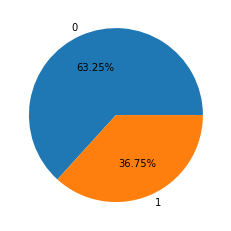

In [22]:
plt.pie(pacientes['Best RECIST response'].value_counts(), 
        labels = pacientes['Best RECIST response'].unique(), autopct='%.2f%%');

Se enumeran también los estudios

In [23]:
b = np.array(pacientes['Base'])
for i, value in enumerate(b):
  if value == 'RIAZ':
    b[i]=0
  elif value == 'HUGO':
    b[i]=1
  else:
    b[i]=2
print(b)
pacientes['Base'].value_counts()

[0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2
 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
 1 1 1 1 1 1]


RIAZ    49
GIDE    40
HUGO    28
Name: Base, dtype: int64

Visualizar la información del primer gen

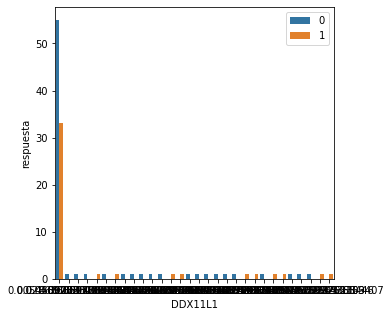

In [24]:
import seaborn as sns
lf = pd.DataFrame()
lf["class"]= pacientes['Best RECIST response']
lf["DDX11L1"] = data["DDX11L1"].values
dfg = lf.groupby(['DDX11L1','class']).size().reset_index(name='respuesta')
plt.figure(figsize=(5,5))
sns.barplot(x='DDX11L1', y='respuesta', data=dfg, hue='class')
plt.legend(loc='upper right')

Diviendo datos entrenamiento y prueba para normalización

In [25]:
from sklearn.model_selection import train_test_split

In [26]:
X_train, X_test, y_train, y_test = train_test_split(data, y, test_size=.15, random_state=42)

Gráfica para ver la relación entre los dos primeros genes

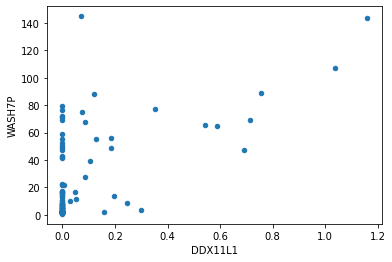

In [27]:
X_train.plot.scatter(x='DDX11L1', y='WASH7P')

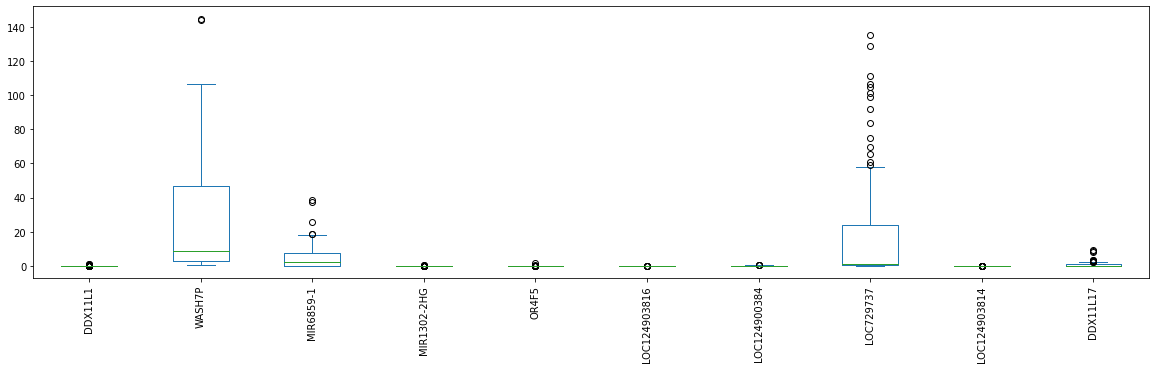

In [28]:
data_primeros = X_train.iloc[:,0:10]
data_primeros.plot.box(figsize=(20,5), rot=90)

# Normalización

In [29]:
from sklearn.preprocessing import MinMaxScaler

In [30]:
norm = MinMaxScaler().fit(X_train)
X_train_norm = norm.transform(X_train)
X_test_norm = norm.transform(X_test)

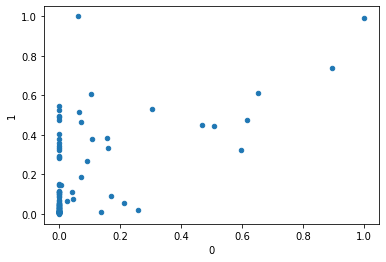

In [31]:
pd.DataFrame(X_train_norm).plot.scatter(x=0, y=1)

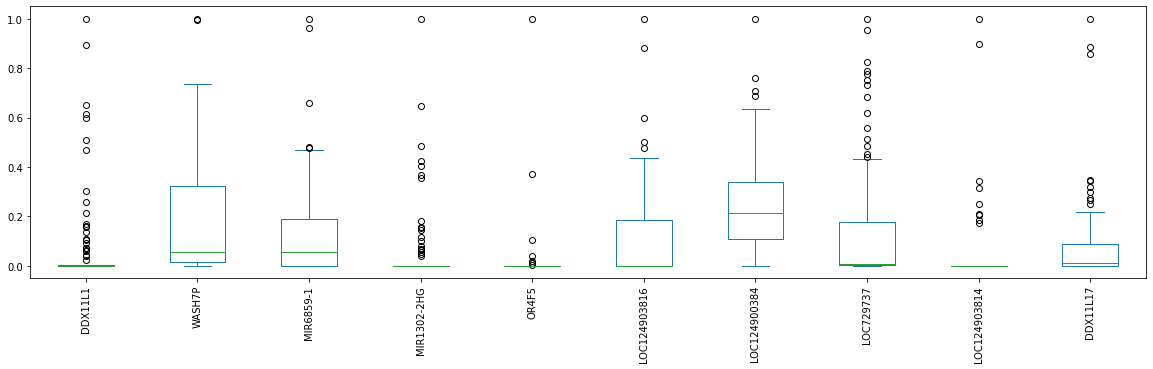

In [32]:
pd.DataFrame(X_train_norm[:,0:10], columns=data.columns[0:10]).plot.box(figsize=(20,5), rot=90)


Estandarización



In [33]:
from sklearn.preprocessing import StandardScaler

In [34]:
scale = StandardScaler().fit(X_train)
X_train_stand = scale.transform(X_train)
X_test_stand = scale.transform(X_test)

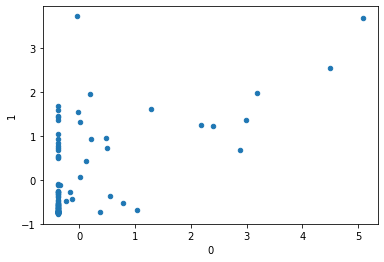

In [35]:
pd.DataFrame(X_train_stand).plot.scatter(x=0, y=1)

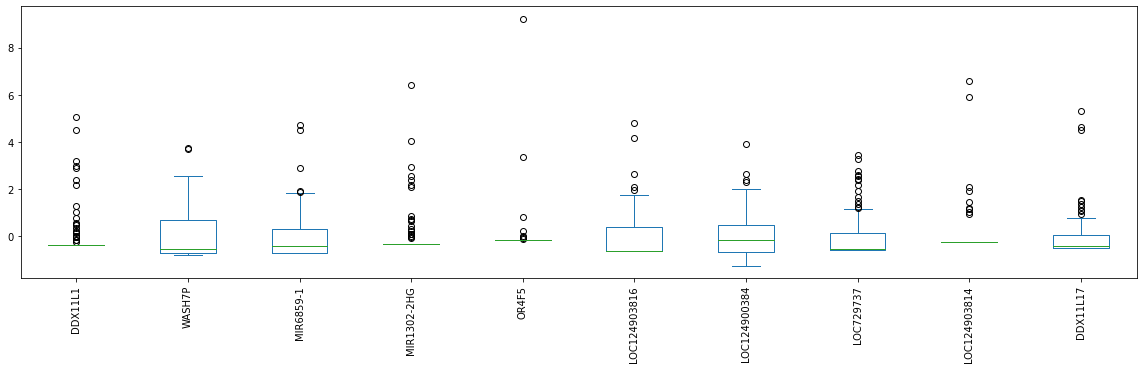

In [36]:
pd.DataFrame(X_train_stand[:,0:10], columns=data.columns[0:10]).plot.box(figsize=(20,5), rot=90)

Utilizando SVM para probar la normalización y estarización

In [37]:
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score

score = []

trainX = [X_train, X_train_norm, X_train_stand]
testX = [X_test, X_test_norm, X_test_stand]

for train, test in zip(trainX, testX):
    svc = SVC()
    
    svc.fit(train, y_train)
    y_pred = svc.predict(test)

    score.append(accuracy_score(y_test, y_pred))

df_svr = pd.DataFrame({'Accuracy': score}, index=['Original', 'Normalizado', 'Estandarizado'])
df_svr

,Accuracy
Original,0.666667
Normalizado,0.666667
Estandarizado,0.666667


Realizaremos análisis con datos originales (data) y con tados estadarizados (datos)

In [38]:
norm = MinMaxScaler().fit(data)
data_norm = norm.transform(data)

scale = StandardScaler().fit(data)
data_stand = scale.transform(data)

datos = data_stand

datos.shape

(117, 39048)

# Análisis de Componentes Principales

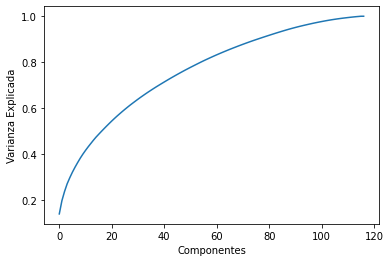

In [ ]:
pca = PCA().fit(datos)
plt.plot(np.cumsum(pca.explained_variance_ratio_))
plt.xlabel('Componentes')
plt.ylabel('Varianza Explicada');


De acuerdo con la gráfica, logramos explicar la información con 115 componentes

Analizar qué puede verse con 2 componentes principales, indicando con colores los pacientes que responden y los que no responden

In [ ]:
pca = PCA(n_components = 2)
pca.fit(datos)
x_pca = pca.transform(datos)

Text(0, 0.5, 'PC2')

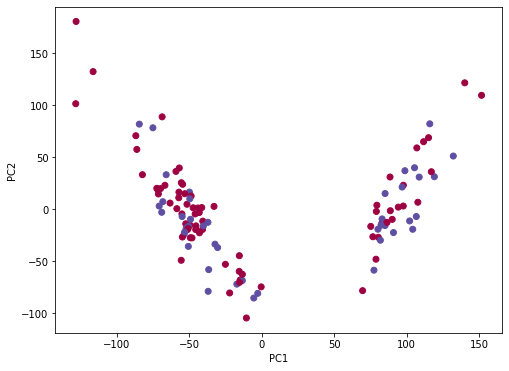

In [ ]:
plt.figure(figsize =(8, 6))
plt.scatter(x_pca[:, 0], x_pca[:, 1], c = y, cmap ='Spectral')
plt.xlabel('PC1')
plt.ylabel('PC2')

Indicando los pacientes de cada estudio
Se puede observar un efecto batch. Los del estudio azul provienen de una base de datos diferentes a las de los otros dos. (tiene tamaños de lectura más cortos)

Text(0, 0.5, 'PC2')

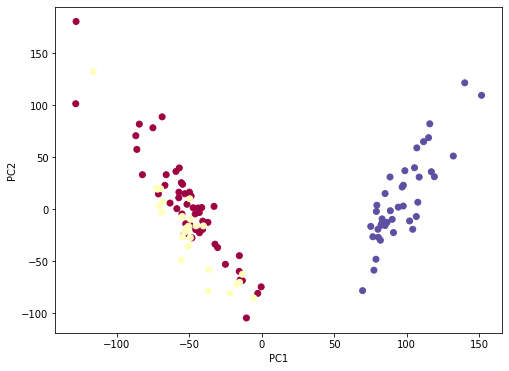

In [ ]:
plt.figure(figsize =(8, 6))
plt.scatter(x_pca[:, 0], x_pca[:, 1], c = b, cmap ='Spectral')
plt.xlabel('PC1')
plt.ylabel('PC2')

In [ ]:
df_comp = pd.DataFrame(pca.components_, columns = data.columns)
df_comp

Geneid,DDX11L1,WASH7P,MIR6859-1,MIR1302-2HG,OR4F5,LOC124903816,LOC124900384,LOC729737,LOC124903814,DDX11L17,...,DAZ1,DAZ2,GOLGA2P2Y,DAZ3,DAZ4,SEPTIN14P23,GOLGA2P3Y,CSPG4P1Y,REREP2Y,LOC105377244
0,0.004936,0.011258,-0.006415,-0.003758,0.002850,0.007144,-0.001269,0.010041,-0.002544,0.008365,...,0.002860,0.002802,0.003348,0.002786,0.000009,0.007570,0.001708,0.005374,-0.001884,-0.002237
1,0.005022,0.005959,-0.001183,0.004751,0.004883,0.004590,0.005106,0.003694,0.001585,0.007840,...,0.002862,0.002525,0.004717,0.001814,0.000264,0.005404,0.000890,0.005506,0.001382,-0.001073


Visualizar los genes con más aporte (azules o rojos)

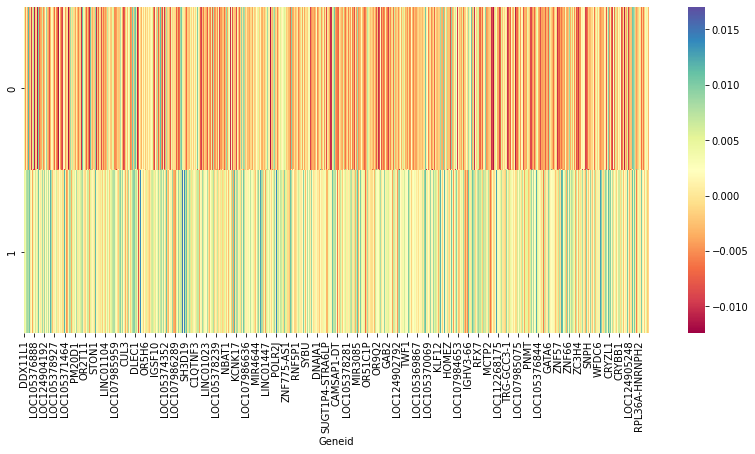

In [ ]:
import seaborn as sns
plt.figure(figsize =(14, 6))
sns.heatmap(df_comp, cmap='Spectral')

#Clusterización

La realizo para ver si se pueden apreciar clusters que permitan clasificar los que responden y no responden o entre bases de datos

In [ ]:
from sklearn import cluster, datasets, mixture
from sklearn.cluster import KMeans
from sklearn.neighbors import kneighbors_graph
from itertools import cycle, islice
from scipy.cluster.hierarchy import dendrogram
from sklearn.cluster import AgglomerativeClustering
from sklearn.metrics import silhouette_score
from sklearn.metrics import adjusted_rand_score

In [ ]:
kmeans=KMeans(n_clusters=2)
kmeans.fit(datos)
pred_kmeans=kmeans.predict(datos)

kmeans_r=KMeans(n_clusters=2, init='random')
kmeans_r.fit(datos)
pred_kmeans_r=kmeans.predict(datos)

dbscan = cluster.DBSCAN(eps=.3)
dbscan.fit(datos)
pred_dbscan=dbscan.labels_.astype(np.int32)

ward = AgglomerativeClustering(n_clusters=3)
ward_pred = ward.fit_predict(datos)

complete = AgglomerativeClustering(n_clusters=2, linkage="complete")
complete_pred = complete.fit_predict(datos)

avg = AgglomerativeClustering(n_clusters=2, linkage="average")
avg_pred = avg.fit_predict(datos)

single = AgglomerativeClustering(n_clusters=2, linkage="single")
single_pred = single.fit_predict(datos)

Para agrupar los que responden y no responden

In [ ]:
pred_kmeans_score = adjusted_rand_score(y, pred_kmeans)
pred_kmeans_r_score = adjusted_rand_score(y, pred_kmeans_r)
pred_dbscan_score = adjusted_rand_score(y, pred_dbscan)
ward_ar_score = adjusted_rand_score(y, ward_pred)
complete_ar_score = adjusted_rand_score(y, complete_pred)
single_ar_score = adjusted_rand_score(y, single_pred)
average_ar_score = adjusted_rand_score(y, avg_pred)

In [ ]:
name_pred=['kmeans','kmeans_r','Dbscan','ward','complete','single','average']
df_result=pd.DataFrame(name_pred)
df_result['indexRand']=[pred_kmeans_score, pred_kmeans_r_score, pred_dbscan_score, ward_ar_score, complete_ar_score, single_ar_score,average_ar_score]
df_result

,0,indexRand
0,kmeans,0.024762
1,kmeans_r,0.024762
2,Dbscan,0.000000
3,ward,0.018430
4,complete,-0.007145
5,single,-0.007145
6,average,-0.007145


Para agrupar los diferentes estudios

In [ ]:
pred_kmeans_score = adjusted_rand_score(b, pred_kmeans)
pred_kmeans_r_score = adjusted_rand_score(b, pred_kmeans_r)
pred_dbscan_score = adjusted_rand_score(b, pred_dbscan)
ward_ar_score = adjusted_rand_score(b, ward_pred)
complete_ar_score = adjusted_rand_score(b, complete_pred)
single_ar_score = adjusted_rand_score(b, single_pred)
average_ar_score = adjusted_rand_score(b, avg_pred)

In [ ]:
name_pred=['kmeans','kmeans_r','Dbscan','ward','complete','single','average']
df_result=pd.DataFrame(name_pred)
df_result['indexRand']=[pred_kmeans_score, pred_kmeans_r_score, pred_dbscan_score, ward_ar_score, complete_ar_score, single_ar_score,average_ar_score]
df_result

,0,indexRand
0,kmeans,0.606955
1,kmeans_r,0.606955
2,Dbscan,0.000000
3,ward,0.610611
4,complete,0.005842
5,single,0.005842
6,average,0.005842


# PyCombat

Se intenta utilizar esta herramienta para corregir el efecto batch. Se le pasa la base de conocimiento y se le indica de donde a donde va cada estudio o batch

In [39]:
pip install combat

Looking in indexes: https://pypi.org/simple, https://us-python.pkg.dev/colab-wheels/public/simple/
     |████████████████████████████████| 14.8 MB 7.9 MB/s 
     |████████████████████████████████| 231 kB 55.9 MB/s 
     |████████████████████████████████| 9.5 MB 44.3 MB/s 
  Attempting uninstall: numpy
    Found existing installation: numpy 1.21.6
    Uninstalling numpy-1.21.6:
      Successfully uninstalled numpy-1.21.6
  Attempting uninstall: patsy
    Found existing installation: patsy 0.5.2
    Uninstalling patsy-0.5.2:
      Successfully uninstalled patsy-0.5.2
  Attempting uninstall: pandas
    Found existing installation: pandas 1.3.5
    Uninstalling pandas-1.3.5:
      Successfully uninstalled pandas-1.3.5
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
xarray-einstats 0.2.2 requires numpy>=1.21, but you have numpy 1.19.5 which is incompatible.
tensorfl

In [40]:
pip install combat --upgrade

Looking in indexes: https://pypi.org/simple, https://us-python.pkg.dev/colab-wheels/public/simple/


In [41]:
from combat.pycombat import pycombat

In [42]:
# prepare data
# the datasets are dataframes where:
    # the indexes correspond to the gene names
    # the column names correspond to the sample names
# Any number (>=2) of datasets can be treated
dataset_0 = data.transpose()
dataset_1 = dataset_0.iloc[:, 0:49] 
dataset_2 = dataset_0.iloc[:, 49:89] 
dataset_3 = dataset_0.iloc[:, 89:118] 
df_expression = pd.concat([dataset_1,dataset_2,dataset_3],join="inner",axis=1)

batch = []
datasets = [dataset_1,dataset_2,dataset_3]
for j in range(len(datasets)):
    batch.extend([j for _ in range(len(datasets[j].columns))])

# run pyComBat
df_corrected = pycombat(df_expression,batch)
data_corrected = df_corrected.transpose()
data_corrected

Found 3 batches.
Adjusting for 0 covariate(s) or covariate level(s).
Standardizing Data across genes.
Fitting L/S model and finding priors.
Finding parametric adjustments.


/usr/local/lib/python3.7/dist-packages/combat/pycombat.py:162: RuntimeWarning: divide by zero encountered in true_divide
  np.absolute(d_new-d_old)/d_old))  # maximum difference between new and old estimate
/usr/local/lib/python3.7/dist-packages/combat/pycombat.py:166: VisibleDeprecationWarning: Creating an ndarray from ragged nested sequences (which is a list-or-tuple of lists-or-tuples-or ndarrays with different lengths or shapes) is deprecated. If you meant to do this, you must specify 'dtype=object' when creating the ndarray.
  adjust = np.asarray([g_new, d_new])


Adjusting the Data


Geneid,DDX11L1,WASH7P,MIR6859-1,MIR1302-2HG,OR4F5,LOC124903816,LOC124900384,LOC729737,LOC124903814,DDX11L17,...,DAZ1,DAZ2,GOLGA2P2Y,DAZ3,DAZ4,SEPTIN14P23,GOLGA2P3Y,CSPG4P1Y,REREP2Y,LOC105377244
1,,,,,,,,,,,,,,,,,,,,,
SRR5088813,0.046028,20.362504,2.627522,0.001888,0.016774,0.006614,0.052220,16.906337,-0.000090,0.809658,...,0.018688,0.119088,0.006873,0.081709,-0.000328,0.601004,0.003395,0.158065,-0.000058,0.001877
SRR5088815,0.046028,20.481485,-0.172457,0.001888,0.016774,0.006614,0.120967,22.666553,-0.000090,0.602693,...,0.018688,0.119088,0.006873,0.081709,-0.000328,0.104008,0.003395,0.158065,-0.000058,0.001877
SRR5088818,0.046028,18.222267,4.320186,0.001888,0.016774,0.006614,0.055462,16.876720,-0.000090,0.489285,...,0.018688,0.119088,0.006873,0.081709,-0.000328,0.104008,0.003395,0.158065,-0.000058,0.001877
SRR5088819,0.046028,21.574509,7.144041,0.001888,0.016774,0.006614,0.086736,14.947343,-0.000090,0.489285,...,0.018688,0.307271,0.006873,0.081709,-0.000328,0.104008,0.003395,0.158065,-0.000058,0.079205
SRR5088821,0.046028,24.727144,3.592032,0.001888,0.016774,0.006614,0.033500,17.790533,-0.000090,0.489285,...,0.018688,0.119088,0.006873,0.081709,-0.000328,0.104008,0.003395,0.158065,-0.000058,0.001877
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
SRR3184302,0.054543,25.943270,4.131119,-0.004380,0.013408,0.013540,-0.026863,14.265388,-0.002559,0.645832,...,0.018944,0.215570,0.006952,0.073645,0.001481,0.136234,0.003471,0.158739,0.014600,0.343099
SRR3184303,0.171000,35.985363,20.730087,0.177618,0.013408,0.017725,0.083214,15.162923,0.034291,0.959110,...,0.018944,0.215570,0.006952,0.073645,0.001481,0.596594,0.003471,0.158739,-0.000488,-0.024815
SRR3184304,0.054543,17.370288,2.049734,-0.004380,0.013408,-0.000875,0.022215,14.425772,-0.002559,0.732686,...,0.018944,0.215570,0.006952,0.073645,0.001481,0.136234,0.003471,0.158739,-0.000488,-0.024815


# Normalización y prueba con datos corregidos

In [43]:
X_train_corr, X_test_corr, y_train_corr, y_test_corr = train_test_split(data_corrected, y, test_size=.15, random_state=42)

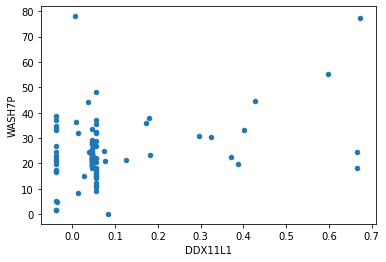

In [44]:
X_train_corr.plot.scatter(x='DDX11L1', y='WASH7P')

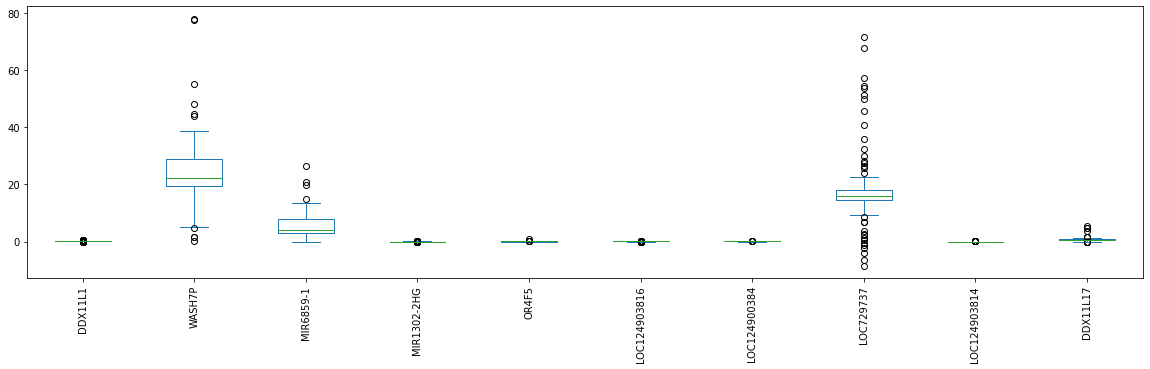

In [45]:
data_primeros_corr = X_train_corr.iloc[:,0:10]
data_primeros_corr.plot.box(figsize=(20,5), rot=90)

In [46]:
norm = MinMaxScaler().fit(X_train_corr)
X_train_norm_corr = norm.transform(X_train_corr)
X_test_norm_corr = norm.transform(X_test_corr)

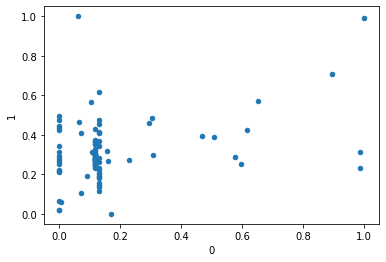

In [47]:
pd.DataFrame(X_train_norm_corr).plot.scatter(x=0, y=1)

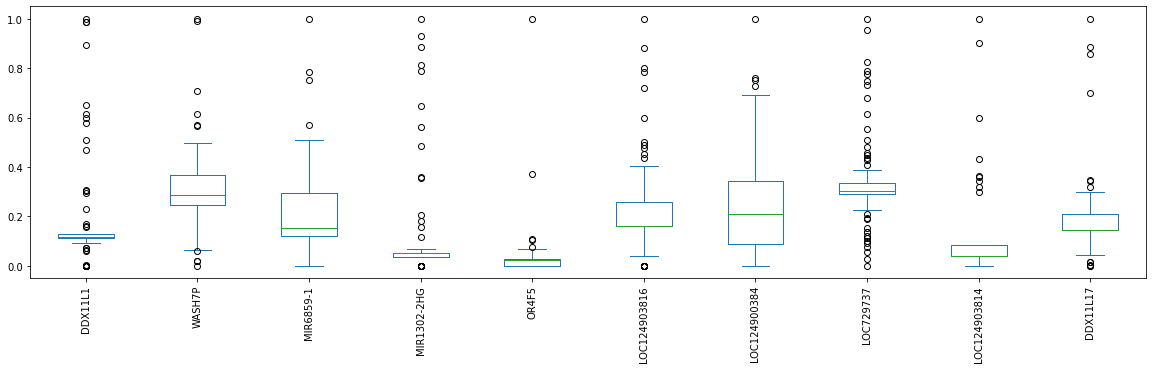

In [48]:
pd.DataFrame(X_train_norm_corr[:,0:10], columns=data.columns[0:10]).plot.box(figsize=(20,5), rot=90)

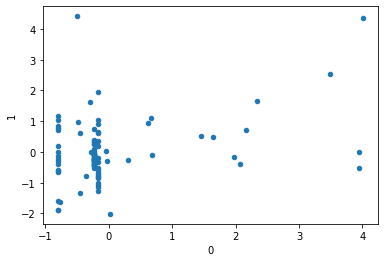

In [49]:
scale = StandardScaler().fit(X_train_corr)
X_train_stand_corr = scale.transform(X_train_corr)
X_test_stand_corr = scale.transform(X_test_corr)
pd.DataFrame(X_train_stand_corr).plot.scatter(x=0, y=1)

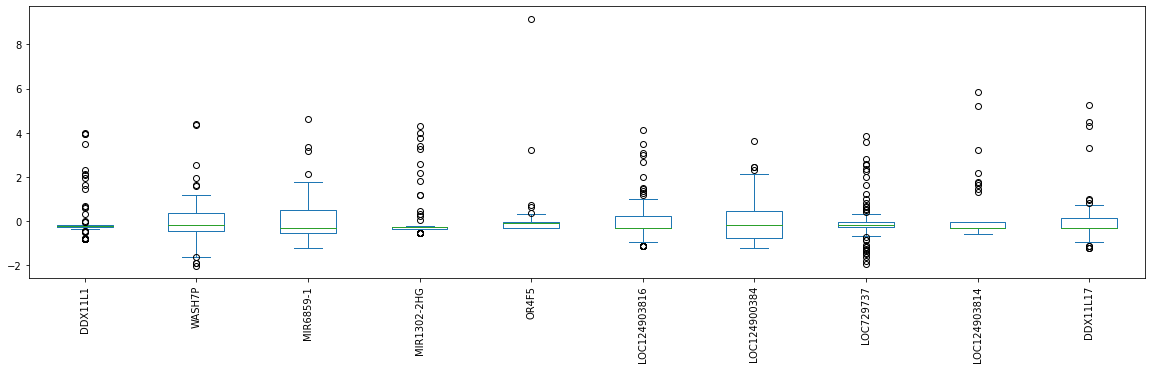

In [50]:
pd.DataFrame(X_train_stand_corr[:,0:10], columns=data.columns[0:10]).plot.box(figsize=(20,5), rot=90)

In [51]:
score_corr = []

trainX_corr = [X_train_corr, X_train_norm_corr, X_train_stand_corr]
testX_corr = [X_test_corr, X_test_norm_corr, X_test_stand_corr]

for train, test in zip(trainX_corr, testX_corr):
    svc = SVC()
    
    svc.fit(train, y_train_corr)
    y_pred = svc.predict(test)

    score_corr.append(accuracy_score(y_test_corr, y_pred))

df_svr = pd.DataFrame({'Accuracy': score_corr}, index=['Original', 'Normalizado', 'Estandarizado'])
df_svr

,Accuracy
Original,0.500000
Normalizado,0.666667
Estandarizado,0.666667


Se obtiene el mismo resultado con los datos corregidos, excepto para la base de datos original donde el desempeño baja

Dejamos como datos corregidos (datos_corr) a aquellos que se les aplicó pycombat y luego se estandarizó

In [52]:
norm = MinMaxScaler().fit(data_corrected)
data_norm_corr = norm.transform(data_corrected)

scale = StandardScaler().fit(data_corrected)
data_stand_corr = scale.transform(data_corrected)

datos_corr = data_norm_corr

datos_corr.shape

(117, 39048)

# Análisis de componentes principales con datos corregidos

Volvemos a analizar con datos corregiodos

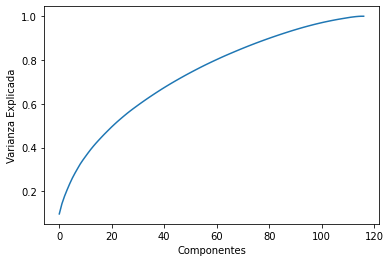

In [ ]:
pca = PCA().fit(datos_corr)
plt.plot(np.cumsum(pca.explained_variance_ratio_))
plt.xlabel('Componentes')
plt.ylabel('Varianza Explicada');

Text(0, 0.5, 'PC2')

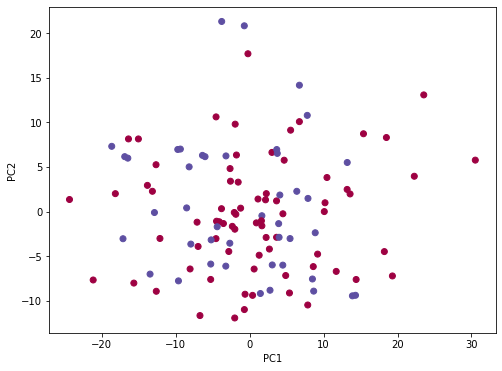

In [ ]:
pca = PCA(n_components = 2)
pca.fit(datos_corr)
x_pca = pca.transform(datos_corr)

plt.figure(figsize =(8, 6))
plt.scatter(x_pca[:, 0], x_pca[:, 1], c = y, cmap ='Spectral')
plt.xlabel('PC1')
plt.ylabel('PC2')

Ya no se ve el efecto batch

Text(0, 0.5, 'PC2')

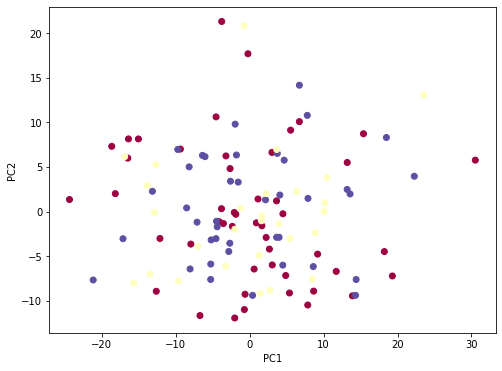

In [ ]:
plt.figure(figsize =(8, 6))
plt.scatter(x_pca[:, 0], x_pca[:, 1], c = b, cmap ='Spectral')
plt.xlabel('PC1')
plt.ylabel('PC2')

# Clusterización con datos corregidos

In [ ]:
kmeans=KMeans(n_clusters=2)
kmeans.fit(datos_corr)
pred_kmeans=kmeans.predict(datos_corr)

kmeans_r=KMeans(n_clusters=2, init='random')
kmeans_r.fit(datos_corr)
pred_kmeans_r=kmeans.predict(datos_corr)

dbscan = cluster.DBSCAN(eps=.3)
dbscan.fit(datos_corr)
pred_dbscan=dbscan.labels_.astype(np.int32)

ward = AgglomerativeClustering(n_clusters=3)
ward_pred = ward.fit_predict(datos_corr)

complete = AgglomerativeClustering(n_clusters=2, linkage="complete")
complete_pred = complete.fit_predict(datos_corr)

avg = AgglomerativeClustering(n_clusters=2, linkage="average")
avg_pred = avg.fit_predict(datos_corr)

single = AgglomerativeClustering(n_clusters=2, linkage="single")
single_pred = single.fit_predict(datos_corr)

In [ ]:
pred_kmeans_score = adjusted_rand_score(y, pred_kmeans)
pred_kmeans_r_score = adjusted_rand_score(y, pred_kmeans_r)
pred_dbscan_score = adjusted_rand_score(y, pred_dbscan)
ward_ar_score = adjusted_rand_score(y, ward_pred)
complete_ar_score = adjusted_rand_score(y, complete_pred)
single_ar_score = adjusted_rand_score(y, single_pred)
average_ar_score = adjusted_rand_score(y, avg_pred)

In [ ]:
name_pred=['kmeans','kmeans_r','Dbscan','ward','complete','single','average']
df_result=pd.DataFrame(name_pred)
df_result['indexRand']=[pred_kmeans_score, pred_kmeans_r_score, pred_dbscan_score, ward_ar_score, complete_ar_score, single_ar_score,average_ar_score]
df_result

,0,indexRand
0,kmeans,-0.006281
1,kmeans_r,-0.006281
2,Dbscan,0.000000
3,ward,0.027466
4,complete,-0.020667
5,single,-0.007145
6,average,-0.007145


In [ ]:
pred_kmeans_score = adjusted_rand_score(b, pred_kmeans)
pred_kmeans_r_score = adjusted_rand_score(b, pred_kmeans_r)
pred_dbscan_score = adjusted_rand_score(b, pred_dbscan)
ward_ar_score = adjusted_rand_score(b, ward_pred)
complete_ar_score = adjusted_rand_score(b, complete_pred)
single_ar_score = adjusted_rand_score(b, single_pred)
average_ar_score = adjusted_rand_score(b, avg_pred)

In [ ]:
name_pred=['kmeans','kmeans_r','Dbscan','ward','complete','single','average']
df_result=pd.DataFrame(name_pred)
df_result['indexRand']=[pred_kmeans_score, pred_kmeans_r_score, pred_dbscan_score, ward_ar_score, complete_ar_score, single_ar_score,average_ar_score]
df_result

,0,indexRand
0,kmeans,-0.005740
1,kmeans_r,-0.005740
2,Dbscan,0.000000
3,ward,-0.006876
4,complete,-0.009323
5,single,0.005842
6,average,0.005842


Ya no podemos apreciar ningún agrupamiento que permita clasificar los estudios

#División de datos para modelos

División del set de datos original. 15% para validación

Los datos originales

In [53]:
X_train, X_val, y_train, y_val= train_test_split(data.values, y, test_size=0.15, random_state=5, stratify=y)
X_train2, X_test, y_train2, y_test= train_test_split(X_train, y_train, test_size=0.15, random_state=5, stratify=y_train)
print(np.unique(y,return_counts=True))
print(np.unique(y_train,return_counts=True))
print(np.unique(y_test,return_counts=True))
print(np.unique(y_val,return_counts=True))

(array([0, 1]), array([74, 43]))
(array([0, 1]), array([63, 36]))
(array([0, 1]), array([10,  5]))
(array([0, 1]), array([11,  7]))


Los datos estandarizados

In [54]:
X_train_s, X_val_s, y_train_s, y_val_s= train_test_split(datos, y, test_size=0.15, random_state=5, stratify=y)
X_train_s2, X_test_s, y_train_s2, y_test_s= train_test_split(X_train_s, y_train_s, test_size=0.15, random_state=5, stratify=y_train_s)

Los datos corregidos

In [55]:
X_train_c, X_val_c, y_train_c, y_val_c= train_test_split(datos_corr, y, test_size=0.15, random_state=5, stratify=y)
X_train_c2, X_test_c, y_train_c2, y_test_c= train_test_split(X_train_c, y_train_c, test_size=0.15, random_state=5, stratify=y_train_c)

In [56]:
from sklearn.model_selection import cross_validate
from sklearn.model_selection import cross_val_score
from sklearn.metrics import recall_score
from sklearn.model_selection import KFold
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import classification_report
from statistics import mean, stdev
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from sklearn.model_selection import GridSearchCV
from sklearn.neighbors import KNeighborsClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.naive_bayes import GaussianNB 
from sklearn.tree import DecisionTreeClassifier
from sklearn.linear_model import LogisticRegression
from sklearn import svm
from sklearn.svm import SVR
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import AdaBoostClassifier
from sklearn.ensemble import BaggingClassifier
from sklearn.ensemble import StackingClassifier

# Validación cruzada

Configuramos los parámetros de los modelos

KNN

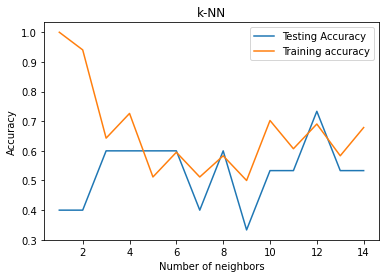

In [ ]:
neighbors = np.arange(1,15)

train_accuracy =np.empty(len(neighbors))
test_accuracy = np.empty(len(neighbors))

for i,k in enumerate(neighbors):
    knn = KNeighborsClassifier(n_neighbors=k)
    knn.fit(X_train_c2, y_train_c2)
    train_accuracy[i] = knn.score(X_train_c2, y_train_c2)
    test_accuracy[i] = knn.score(X_test_c, y_test_c) 

plt.title('k-NN')
plt.plot(neighbors, test_accuracy, label='Testing Accuracy')
plt.plot(neighbors, train_accuracy, label='Training accuracy')
plt.legend()
plt.xlabel('Number of neighbors')
plt.ylabel('Accuracy')
plt.show()

Se selecciona 12 como número de vecinos

MLP

In [ ]:
param_grid = {'hidden_layer_sizes':np.arange(2,15)}
mlp = MLPClassifier(alpha=1e-5,random_state=1, max_iter=2000)
mlp_cv= GridSearchCV(mlp,param_grid,cv=10,n_jobs=-1,verbose=10)
mlp_cv.fit(X_train_c,y_train_c)
print(mlp_cv.best_score_,mlp_cv.best_params_)

Fitting 10 folds for each of 13 candidates, totalling 130 fits
0.6366666666666666 {'hidden_layer_sizes': 2}


Random Forest

In [ ]:
param_grid = {'n_estimators':[10, 50, 100],
              'criterion':["gini", "entropy"]}
rfg = RandomForestClassifier()
rfg_cv= GridSearchCV(rfg,param_grid,cv=10)
rfg_cv.fit(X_train_c,y_train_c)
print(rfg_cv.best_score_,rfg_cv.best_params_)

0.6555555555555556 {'criterion': 'gini', 'n_estimators': 100}


Suport Vector Machine

In [ ]:
score_svm = []

svm= SVC(kernel='linear', C=1).fit(X_train_c2, y_train_c2)
y_pred_svm = svm.predict(X_test_c)
score_svm.append(accuracy_score(y_test_c, y_pred_svm))

svm_rbf = SVC(kernel='rbf', C=100, gamma=0.1).fit(X_train_c2, y_train_c2)
y_pred_rbf = svm_rbf.predict(X_test_c)
score_svm.append(accuracy_score(y_test_c, y_pred_rbf))

svm_lin = SVC(kernel='linear', C=100, gamma='auto').fit(X_train_c2, y_train_c2)
y_pred_lin = svm_lin.predict(X_test_c)
score_svm.append(accuracy_score(y_test_c, y_pred_lin))

svm_poly = SVC(kernel='poly', C=100, gamma='auto', degree=3, coef0=1).fit(X_train_c2, y_train_c2)
y_pred_poly = svm_poly.predict(X_test_c)
score_svm.append(accuracy_score(y_test_c, y_pred_poly))
score_svm

[0.6, 0.6666666666666666, 0.6, 0.6]

rbf

Función para validación cruzada de validación de varios modelos

In [ ]:
from sklearn.base import clone
from sklearn.model_selection import StratifiedKFold
from statistics import mean, stdev
import itertools

def cvClassifiers(X, Y, list_Classifiers):
  strtfdKFold = StratifiedKFold(n_splits=10)
  kfold = strtfdKFold.split(X, Y)
  scores = [[] for c in list_Classifiers]
  predicted_y=[[] for c in list_Classifiers]
  real_y=[[] for c in list_Classifiers]
  for train_index, test_index in kfold:
    for i,c in enumerate(list_Classifiers):    
      model = clone(c)
      X_train_cv, X_test_cv = X[train_index], X[test_index]
      y_train_cv, y_test_cv = Y[train_index], Y[test_index]
      model.fit(X_train_cv, y_train_cv)
      scores[i].append(model.score(X_test_cv,y_test_cv))
      py=model.predict(X_test_cv)
      predicted_y[i]=list(itertools.chain(predicted_y[i],py.flatten().tolist()))
      real_y[i]=list(itertools.chain(real_y[i],y_test_cv.flatten().tolist()))
  accuracy=[mean(sc)*100 for sc in scores]
  cm=[confusion_matrix(real_y[i],predicted_y[i]) for i in range(0,len(list_Classifiers))]
  return accuracy, cm
  

estimators = [
('svm', SVC()),
('mlp', MLPClassifier(hidden_layer_sizes=17, alpha=1e-5,random_state=1, max_iter=2000))
]

list_Classifiers=[
              GaussianNB(),
              DecisionTreeClassifier(criterion='entropy'),
              LogisticRegression(),
              SVC(kernel='rbf', C=100, gamma=0.1), 
              KNeighborsClassifier(n_neighbors=12,metric='euclidean'),
              MLPClassifier(hidden_layer_sizes=2, alpha=1e-5,random_state=1, max_iter=2000),
              BaggingClassifier(n_estimators=10),
              AdaBoostClassifier(n_estimators=50),
              StackingClassifier(estimators=estimators, final_estimator=LogisticRegression()),
              RandomForestClassifier(n_estimators=100, criterion="gini"),
              GradientBoostingClassifier(n_estimators=10)
]

name_Classifiers=[
              "Naive Bayes",
              "Ábol de Decisión",
              "Regresión Logística",
              "Support Vector Machine",
              "KNN",
              "MLP",
              "BaggingClassifier",
              "AdaBoostClassifier",
              "StackingClassifier",
              "RandomForest",
              "GradientBoosting"
]

Probamos con los datos originales

In [ ]:
a , c = cvClassifiers(X_train, y_train, list_Classifiers)

/usr/local/lib/python3.7/dist-packages/sklearn/linear_model/_logistic.py:818: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  extra_warning_msg=_LOGISTIC_SOLVER_CONVERGENCE_MSG,
/usr/local/lib/python3.7/dist-packages/sklearn/linear_model/_logistic.py:818: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression


Probamos como datos estandarizados 

In [ ]:
a_s , c_s = cvClassifiers(X_train_s, y_train_s, list_Classifiers)

Probamos con los datos con corrección de efecto batch

In [ ]:
a_c , c_c = cvClassifiers(X_train_c, y_train_c, list_Classifiers)

/usr/local/lib/python3.7/dist-packages/sklearn/linear_model/_logistic.py:818: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  extra_warning_msg=_LOGISTIC_SOLVER_CONVERGENCE_MSG,
/usr/local/lib/python3.7/dist-packages/sklearn/linear_model/_logistic.py:818: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression


In [ ]:
resultado = pd.DataFrame()
resultado ["Original"] = a
resultado ["Estandarizado"] = a_s
resultado ["Sin Batch"] = a_c
resultado ["Modelo"]= name_Classifiers
resultado

,Original,Estandarizado,Sin Batch,Modelo
0,58.555556,63.777778,61.777778,Naive Bayes
1,63.555556,61.555556,54.666667,Ábol de Decisión
2,56.444444,66.777778,48.444444,Regresión Logística
3,63.666667,63.666667,63.666667,Support Vector Machine
4,67.666667,59.666667,54.666667,KNN
5,63.666667,55.777778,63.666667,MLP
6,64.777778,60.555556,64.444444,BaggingClassifier
7,56.444444,56.444444,70.666667,AdaBoostClassifier
8,63.666667,63.666667,63.666667,StackingClassifier
9,65.666667,61.555556,63.666667,RandomForest


KNN original


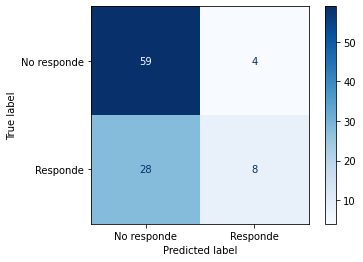

In [ ]:
print("KNN original")
disp = ConfusionMatrixDisplay(confusion_matrix=c[4], display_labels=["No responde", "Responde"])
disp.plot(cmap=plt.cm.Blues)


Regresión logística estandarizado


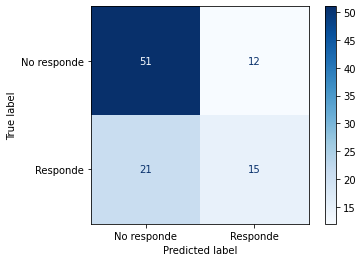

In [ ]:
print("Regresión logística estandarizado")
disp = ConfusionMatrixDisplay(confusion_matrix=c_s[2], display_labels=["No responde", "Responde"])
disp.plot(cmap=plt.cm.Blues)

AdaBoost original


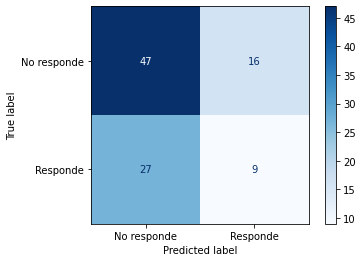

In [ ]:
print("AdaBoost original")
disp = ConfusionMatrixDisplay(confusion_matrix=c[7], display_labels=["No responde", "Responde"])
disp.plot(cmap=plt.cm.Blues)

Random Forest Original


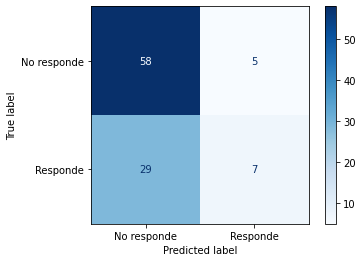

In [ ]:
print("Random Forest Original")
disp = ConfusionMatrixDisplay(confusion_matrix=c[9], display_labels=["No responde", "Responde"])
disp.plot(cmap=plt.cm.Blues)


GradientBoosting original


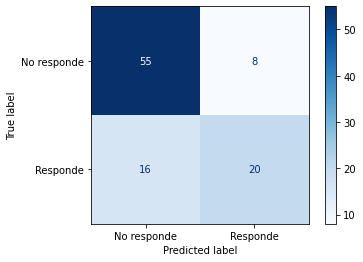

In [ ]:
print("GradientBoosting original")
disp = ConfusionMatrixDisplay(confusion_matrix=c[10], display_labels=["No responde", "Responde"])
disp.plot(cmap=plt.cm.Blues)

# Entrenamiento, prueba y validación de 5 modelos


Gradient boostig original

In [ ]:
gb = GradientBoostingClassifier(n_estimators=10)
gb.fit(X_train2,y_train2)

GradientBoostingClassifier(n_estimators=10)

              precision    recall  f1-score   support

           0       0.67      0.80      0.73        10
           1       0.33      0.20      0.25         5

    accuracy                           0.60        15
   macro avg       0.50      0.50      0.49        15
weighted avg       0.56      0.60      0.57        15



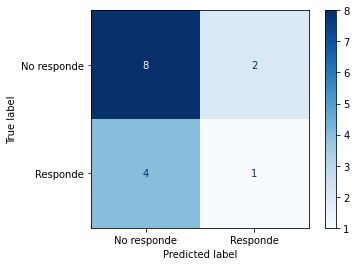

In [ ]:
y_predict_test=gb.predict(X_test)
print(classification_report(y_test,y_predict_test))
cm=confusion_matrix(y_test,y_predict_test)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["No responde", "Responde"])
disp.plot(cmap=plt.cm.Blues)

              precision    recall  f1-score   support

           0       0.62      0.91      0.74        11
           1       0.50      0.14      0.22         7

    accuracy                           0.61        18
   macro avg       0.56      0.53      0.48        18
weighted avg       0.58      0.61      0.54        18



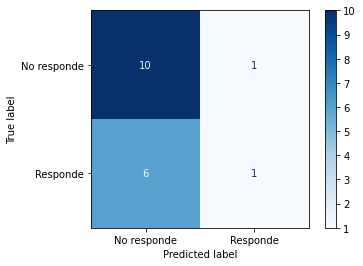

In [ ]:
y_predict_val=gb.predict(X_val)
print(classification_report(y_val,y_predict_val))
cm=confusion_matrix(y_val,y_predict_val)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["No responde", "Responde"])
disp.plot(cmap=plt.cm.Blues)

AdaBoost Corregido

In [ ]:
dt =  AdaBoostClassifier(n_estimators=50)
dt.fit(X_train_c2,y_train_c2)

AdaBoostClassifier()

              precision    recall  f1-score   support

           0       0.71      1.00      0.83        10
           1       1.00      0.20      0.33         5

    accuracy                           0.73        15
   macro avg       0.86      0.60      0.58        15
weighted avg       0.81      0.73      0.67        15



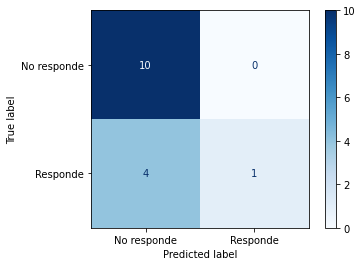

In [ ]:
y_predict_test=dt.predict(X_test_c)
print(classification_report(y_test_c,y_predict_test))
cm=confusion_matrix(y_test_c,y_predict_test)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["No responde", "Responde"])
disp.plot(cmap=plt.cm.Blues)

              precision    recall  f1-score   support

           0       0.67      0.91      0.77        11
           1       0.67      0.29      0.40         7

    accuracy                           0.67        18
   macro avg       0.67      0.60      0.58        18
weighted avg       0.67      0.67      0.63        18



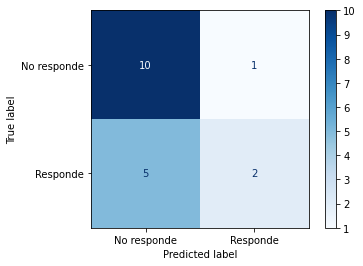

In [ ]:
y_predict_val=dt.predict(X_val_c)
print(classification_report(y_val_c,y_predict_val))
cm=confusion_matrix(y_val_c,y_predict_val)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["No responde", "Responde"])
disp.plot(cmap=plt.cm.Blues)

KNN original

In [ ]:
ml = KNeighborsClassifier(n_neighbors=12,metric='euclidean')
ml.fit(X_train2,y_train2)

KNeighborsClassifier(metric='euclidean', n_neighbors=12)

              precision    recall  f1-score   support

           0       0.71      1.00      0.83        10
           1       1.00      0.20      0.33         5

    accuracy                           0.73        15
   macro avg       0.86      0.60      0.58        15
weighted avg       0.81      0.73      0.67        15



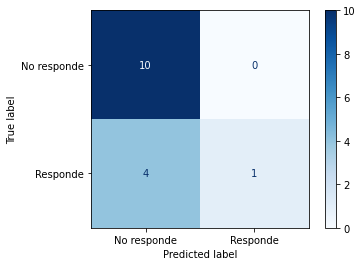

In [ ]:
y_predict_test=ml.predict(X_test)
print(classification_report(y_test,y_predict_test))
cm=confusion_matrix(y_test,y_predict_test)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["No responde", "Responde"])
disp.plot(cmap=plt.cm.Blues)

              precision    recall  f1-score   support

           0       0.65      1.00      0.79        11
           1       1.00      0.14      0.25         7

    accuracy                           0.67        18
   macro avg       0.82      0.57      0.52        18
weighted avg       0.78      0.67      0.58        18



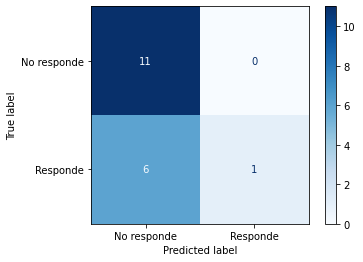

In [ ]:
y_predict_val=ml.predict(X_val)
print(classification_report(y_val,y_predict_val))
cm=confusion_matrix(y_val,y_predict_val)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["No responde", "Responde"])
disp.plot(cmap=plt.cm.Blues)

Regresión Logística estandarizado

In [ ]:
sup = LogisticRegression()
sup.fit(X_train_s2,y_train_s2)

LogisticRegression()

              precision    recall  f1-score   support

           0       0.77      1.00      0.87        10
           1       1.00      0.40      0.57         5

    accuracy                           0.80        15
   macro avg       0.88      0.70      0.72        15
weighted avg       0.85      0.80      0.77        15



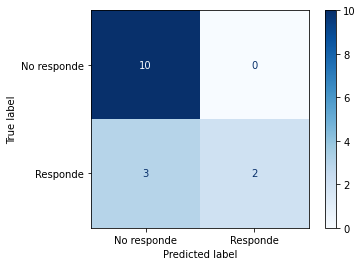

In [ ]:
y_predict_test=sup.predict(X_test_s)
print(classification_report(y_test_s,y_predict_test))
cm=confusion_matrix(y_test_s,y_predict_test)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["No responde", "Responde"])
disp.plot(cmap=plt.cm.Blues)

              precision    recall  f1-score   support

           0       0.71      0.91      0.80        11
           1       0.75      0.43      0.55         7

    accuracy                           0.72        18
   macro avg       0.73      0.67      0.67        18
weighted avg       0.73      0.72      0.70        18



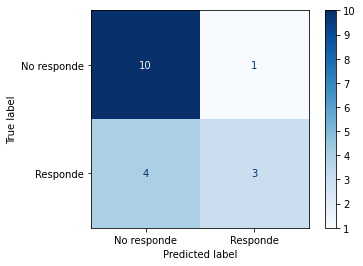

In [ ]:
y_predict_val=sup.predict(X_val_s)
print(classification_report(y_val_s,y_predict_val))
cm=confusion_matrix(y_val_s,y_predict_val)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["No responde", "Responde"])
disp.plot(cmap=plt.cm.Blues)

Random Forest original

In [ ]:
rfo = RandomForestClassifier(n_estimators=100, criterion="gini")
rfo.fit(X_train2,y_train2)

RandomForestClassifier()

              precision    recall  f1-score   support

           0       0.71      1.00      0.83        10
           1       1.00      0.20      0.33         5

    accuracy                           0.73        15
   macro avg       0.86      0.60      0.58        15
weighted avg       0.81      0.73      0.67        15



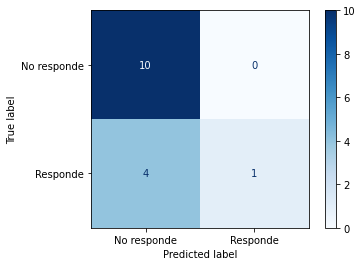

In [ ]:
y_predict_test=sup.predict(X_test)
print(classification_report(y_test,y_predict_test))
cm=confusion_matrix(y_test,y_predict_test)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["No responde", "Responde"])
disp.plot(cmap=plt.cm.Blues)

              precision    recall  f1-score   support

           0       0.69      1.00      0.81        11
           1       1.00      0.29      0.44         7

    accuracy                           0.72        18
   macro avg       0.84      0.64      0.63        18
weighted avg       0.81      0.72      0.67        18



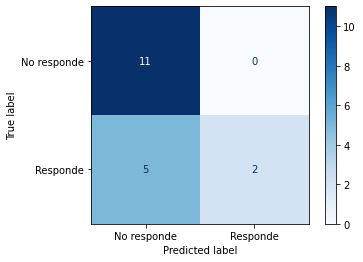

In [ ]:
y_predict_val=sup.predict(X_val)
print(classification_report(y_val,y_predict_val))
cm=confusion_matrix(y_val,y_predict_val)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["No responde", "Responde"])
disp.plot(cmap=plt.cm.Blues)

Los mejores resultados de obtienes con regresión logística y random forest

#Con datos balanceados

Creamos una sola base de conocimiento

In [109]:
ensayo=pd.DataFrame(X_train)
ensayo.columns = data.columns
ensayo["target"] = y_train
guardar = ensayo
guardar

Geneid,DDX11L1,WASH7P,MIR6859-1,MIR1302-2HG,OR4F5,LOC124903816,LOC124900384,LOC729737,LOC124903814,DDX11L17,...,DAZ2,GOLGA2P2Y,DAZ3,DAZ4,SEPTIN14P23,GOLGA2P3Y,CSPG4P1Y,REREP2Y,LOC105377244,target
0,0.0,1.977705,1.143320,0.000000,0.000000,0.027816,0.109347,0.085216,0.000000,0.048379,...,0.0,0.0,0.0,0.0,0.369339,0.0,0.0,0.0,0.000000,0
1,0.0,2.611411,1.045155,0.000000,0.000000,0.000000,0.000000,0.064916,0.000000,0.000000,...,0.0,0.0,0.0,0.0,0.422034,0.0,0.0,0.0,0.000000,0
2,0.0,3.052868,6.269957,0.000000,0.000000,0.000000,0.083286,0.129813,0.000000,0.000000,...,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,0.0,0.014209,0
3,0.0,7.888783,25.559079,0.000000,0.000000,0.009145,0.143792,1.596859,0.000000,0.000000,...,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,0.0,0.000000,0
4,0.0,1.820773,6.631364,0.000000,0.000000,0.000000,0.060402,0.211827,0.000000,0.000000,...,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,0.0,0.000000,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
94,0.0,1.957288,0.000000,0.000000,0.000000,0.000000,0.000000,0.589398,0.000000,0.000000,...,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,0.0,0.000000,0
95,0.0,14.922009,17.100955,0.017129,0.014806,0.020803,0.163553,0.205353,0.014309,0.289450,...,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,0.0,0.333288,0
96,0.0,2.443211,0.993116,0.000000,0.000000,0.000000,0.063321,0.271411,0.074786,0.000000,...,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,0.0,0.000000,0
97,0.0,2.734352,0.827132,0.000000,0.000000,0.000000,0.105476,0.339073,0.000000,0.070000,...,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,0.0,0.000000,0


sacamos los datos de pacientes que responden

In [58]:
responden = ensayo[ensayo ["target"]==1]
responden

Geneid,DDX11L1,WASH7P,MIR6859-1,MIR1302-2HG,OR4F5,LOC124903816,LOC124900384,LOC729737,LOC124903814,DDX11L17,...,DAZ2,GOLGA2P2Y,DAZ3,DAZ4,SEPTIN14P23,GOLGA2P3Y,CSPG4P1Y,REREP2Y,LOC105377244,target
6,0.000000,8.004348,8.904605,0.020582,0.0,0.008332,0.087347,5.530811,0.017194,0.000000,...,0.000000,0.0,0.000000,0.000000,0.055318,0.0,0.000000,0.0,0.000000,1
10,0.352370,77.471129,0.000000,0.000000,0.0,0.029753,0.019493,29.243978,0.000000,1.138459,...,0.000000,0.0,0.000000,0.000000,0.395056,0.0,0.104603,0.0,0.000000,1
14,0.000000,54.998197,0.000000,0.000000,0.0,0.021540,0.000000,92.122730,0.000000,3.296869,...,0.000000,0.0,0.000000,0.000000,1.144044,0.0,0.454380,0.0,0.000000,1
15,0.000000,8.499531,5.083053,0.000000,0.0,0.000000,0.040512,0.389385,0.000000,0.107544,...,0.000000,0.0,0.000000,0.000000,0.000000,0.0,0.000000,0.0,0.000000,1
16,0.000000,47.092963,1.081297,0.000000,0.0,0.000000,0.068943,15.890366,0.000000,1.647178,...,0.000000,0.0,0.000000,0.000000,0.174651,0.0,0.000000,0.0,0.000000,1
17,0.000000,1.743398,11.602181,0.000000,0.0,0.000000,0.016813,0.576506,0.000000,0.044631,...,0.000000,0.0,0.000000,0.000000,0.000000,0.0,0.000000,0.0,0.000000,1
20,0.000000,16.551602,18.660990,0.020768,0.0,0.016815,0.187287,0.738369,0.000000,0.204721,...,0.034048,0.0,0.013754,0.000000,0.000000,0.0,0.000000,0.0,0.178557,1
21,0.000000,6.156949,18.157060,0.000000,0.0,0.031553,0.124039,0.692772,0.000000,0.027440,...,0.000000,0.0,0.000000,0.000000,0.209481,0.0,0.000000,0.0,0.000000,1
23,0.692228,47.028878,0.000000,0.000000,0.0,0.017048,0.178709,75.137173,0.000000,0.000000,...,0.000000,0.0,0.000000,0.000000,0.339537,0.0,0.000000,0.0,0.000000,1
24,0.000000,59.254840,0.000000,0.000000,0.0,0.094610,0.123973,105.078151,0.000000,1.579695,...,14.636169,0.0,6.933955,0.000000,0.502488,0.0,0.266098,0.0,0.000000,1


Pegamos de nuevo los que respoden a la matriz de conocimiento para que queden duplicados

In [59]:
balanceado = pd.concat([ensayo, responden])
y2=balanceado["target"]
balanceado = balanceado.iloc[:,:-1]
balanceado


Geneid,DDX11L1,WASH7P,MIR6859-1,MIR1302-2HG,OR4F5,LOC124903816,LOC124900384,LOC729737,LOC124903814,DDX11L17,...,DAZ1,DAZ2,GOLGA2P2Y,DAZ3,DAZ4,SEPTIN14P23,GOLGA2P3Y,CSPG4P1Y,REREP2Y,LOC105377244
0,0.0,1.977705,1.143320,0.000000,0.0,0.027816,0.109347,0.085216,0.000000,0.048379,...,0.000000,0.000000,0.0,0.0,0.0,0.369339,0.0,0.00000,0.0,0.000000
1,0.0,2.611411,1.045155,0.000000,0.0,0.000000,0.000000,0.064916,0.000000,0.000000,...,0.000000,0.000000,0.0,0.0,0.0,0.422034,0.0,0.00000,0.0,0.000000
2,0.0,3.052868,6.269957,0.000000,0.0,0.000000,0.083286,0.129813,0.000000,0.000000,...,0.000000,0.000000,0.0,0.0,0.0,0.000000,0.0,0.00000,0.0,0.014209
3,0.0,7.888783,25.559079,0.000000,0.0,0.009145,0.143792,1.596859,0.000000,0.000000,...,0.000000,0.000000,0.0,0.0,0.0,0.000000,0.0,0.00000,0.0,0.000000
4,0.0,1.820773,6.631364,0.000000,0.0,0.000000,0.060402,0.211827,0.000000,0.000000,...,0.000000,0.000000,0.0,0.0,0.0,0.000000,0.0,0.00000,0.0,0.000000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
84,0.0,41.497390,1.474785,0.044315,0.0,0.035880,0.117540,26.820929,0.000000,3.057861,...,0.000000,0.000000,0.0,0.0,0.0,2.382075,0.0,0.25229,0.0,0.000000
86,0.0,42.098791,0.000000,0.000000,0.0,0.016488,0.108028,18.984443,0.000000,0.487516,...,0.000000,0.000000,0.0,0.0,0.0,0.109465,0.0,0.00000,0.0,0.000000
89,0.0,14.385957,15.857900,0.000000,0.0,0.000000,0.050555,1.083459,0.000000,0.134205,...,0.000000,0.000000,0.0,0.0,0.0,0.000000,0.0,0.00000,0.0,0.000000
91,0.0,15.098842,12.828353,0.110135,0.0,0.000000,0.155797,1.403872,0.015334,0.000000,...,0.000000,0.000000,0.0,0.0,0.0,0.000000,0.0,0.00000,0.0,0.000000


Dividimos los datos en etrenamiento y prueba. El set de validación no se toca. 

In [60]:
X_train2, X_test, y_train2, y_test= train_test_split(balanceado.values, y2.values, test_size=0.15, random_state=5, stratify=y2.values)
print(np.unique(y2,return_counts=True))
print(np.unique(y_train2,return_counts=True))
print(np.unique(y_test,return_counts=True))
print(np.unique(y_val,return_counts=True))


(array([0, 1]), array([63, 72]))
(array([0, 1]), array([53, 61]))
(array([0, 1]), array([10, 11]))
(array([0, 1]), array([11,  7]))


Hacemos nuevamente comparación de modelos con los datos balanceados

In [ ]:
a , c = cvClassifiers(balanceado.values, y2.values, list_Classifiers)

/usr/local/lib/python3.7/dist-packages/sklearn/linear_model/_logistic.py:818: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  extra_warning_msg=_LOGISTIC_SOLVER_CONVERGENCE_MSG,
/usr/local/lib/python3.7/dist-packages/sklearn/linear_model/_logistic.py:818: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression


In [ ]:
resultado_v = pd.DataFrame()
resultado_v ["Balanceado"] = a
resultado_v ["Modelo"]= name_Classifiers
resultado_v

,Balanceado,Modelo
0,84.505495,Naive Bayes
1,85.164835,Ábol de Decisión
2,84.670330,Regresión Logística
3,100.000000,Support Vector Machine
4,61.538462,KNN
5,46.648352,MLP
6,79.450549,BaggingClassifier
7,86.593407,AdaBoostClassifier
8,82.362637,StackingClassifier
9,84.505495,RandomForest


Suport Vector Machine

In [ ]:
s1 = SVC(kernel='rbf', C=100, gamma=0.1)
s1.fit(X_train2,y_train2)

SVC(C=100, gamma=0.1)

              precision    recall  f1-score   support

           0       0.83      1.00      0.91        10
           1       1.00      0.82      0.90        11

    accuracy                           0.90        21
   macro avg       0.92      0.91      0.90        21
weighted avg       0.92      0.90      0.90        21



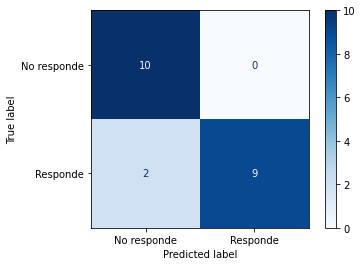

In [ ]:
y_predict_test=s1.predict(X_test)
print(classification_report(y_test,y_predict_test))
cm=confusion_matrix(y_test,y_predict_test)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["No responde", "Responde"])
disp.plot(cmap=plt.cm.Blues)

              precision    recall  f1-score   support

           0       0.61      1.00      0.76        11
           1       0.00      0.00      0.00         7

    accuracy                           0.61        18
   macro avg       0.31      0.50      0.38        18
weighted avg       0.37      0.61      0.46        18



/usr/local/lib/python3.7/dist-packages/sklearn/metrics/_classification.py:1318: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/usr/local/lib/python3.7/dist-packages/sklearn/metrics/_classification.py:1318: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/usr/local/lib/python3.7/dist-packages/sklearn/metrics/_classification.py:1318: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))


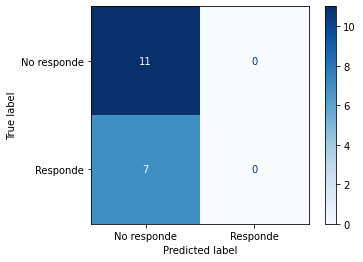

In [ ]:
y_predict_val=s1.predict(X_val)
print(classification_report(y_val,y_predict_val))
cm=confusion_matrix(y_val,y_predict_val)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["No responde", "Responde"])
disp.plot(cmap=plt.cm.Blues)

Bajo con respecto a otros resultados

Random Forest

In [ ]:
rf2 =  RandomForestClassifier()
rf2.fit(X_train2,y_train2)

RandomForestClassifier()

              precision    recall  f1-score   support

           0       1.00      0.50      0.67        10
           1       0.69      1.00      0.81        11

    accuracy                           0.76        21
   macro avg       0.84      0.75      0.74        21
weighted avg       0.84      0.76      0.74        21



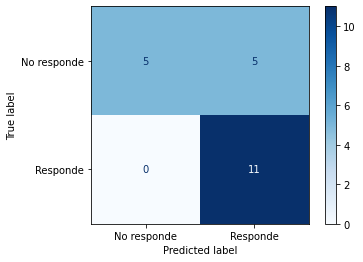

In [ ]:
y_predict_test=rf2.predict(X_test)
print(classification_report(y_test,y_predict_test))
cm=confusion_matrix(y_test, y_predict_test)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["No responde", "Responde"])
disp.plot(cmap=plt.cm.Blues)

              precision    recall  f1-score   support

           0       0.71      0.91      0.80        11
           1       0.75      0.43      0.55         7

    accuracy                           0.72        18
   macro avg       0.73      0.67      0.67        18
weighted avg       0.73      0.72      0.70        18



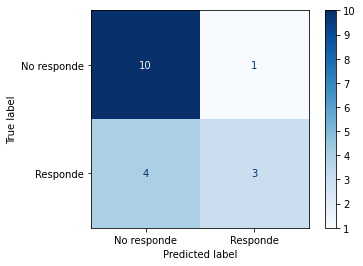

In [ ]:
y_predict_val=rf2.predict(X_val)
print(classification_report(y_val,y_predict_val))
cm=confusion_matrix(y_val,y_predict_val)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["No responde", "Responde"])
disp.plot(cmap=plt.cm.Blues)

GradientBoosting 

In [ ]:
ab = GradientBoostingClassifier(n_estimators=10)
ab.fit(X_train2, y_train2)

GradientBoostingClassifier(n_estimators=10)

              precision    recall  f1-score   support

           0       1.00      0.90      0.95        10
           1       0.92      1.00      0.96        11

    accuracy                           0.95        21
   macro avg       0.96      0.95      0.95        21
weighted avg       0.96      0.95      0.95        21



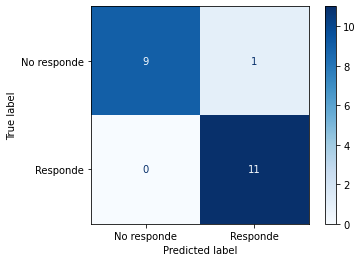

In [ ]:
y_predict_test=ab.predict(X_test)
print(classification_report(y_test,y_predict_test))
cm=confusion_matrix(y_test,y_predict_test)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["No responde", "Responde"])
disp.plot(cmap=plt.cm.Blues)

              precision    recall  f1-score   support

           0       0.67      0.91      0.77        11
           1       0.67      0.29      0.40         7

    accuracy                           0.67        18
   macro avg       0.67      0.60      0.58        18
weighted avg       0.67      0.67      0.63        18



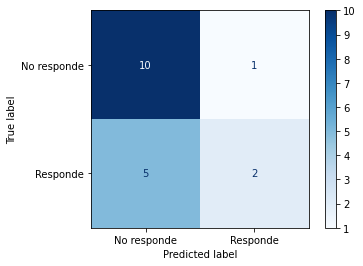

In [ ]:
y_predict_val1=ab.predict(X_val)
print(classification_report(y_val,y_predict_val1))
cm=confusion_matrix(y_val,y_predict_val1)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["No responde", "Responde"])
disp.plot(cmap=plt.cm.Blues)

Regresión logística

In [ ]:
bgb = LogisticRegression(max_iter=500)
bgb.fit(X_train2, y_train2)

LogisticRegression(max_iter=500)

              precision    recall  f1-score   support

           0       0.80      0.80      0.80        10
           1       0.82      0.82      0.82        11

    accuracy                           0.81        21
   macro avg       0.81      0.81      0.81        21
weighted avg       0.81      0.81      0.81        21



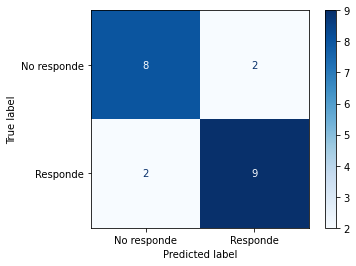

In [ ]:
y_predict_test=bgb.predict(X_test)
print(classification_report(y_test,y_predict_test))
cm=confusion_matrix(y_test,y_predict_test)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["No responde", "Responde"])
disp.plot(cmap=plt.cm.Blues)

              precision    recall  f1-score   support

           0       0.69      0.82      0.75        11
           1       0.60      0.43      0.50         7

    accuracy                           0.67        18
   macro avg       0.65      0.62      0.62        18
weighted avg       0.66      0.67      0.65        18



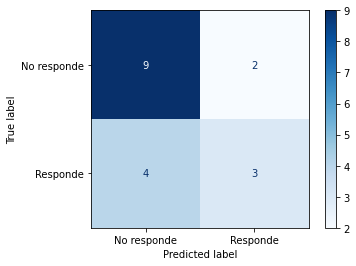

In [ ]:
y_predict_val1=bgb.predict(X_val)
print(classification_report(y_val,y_predict_val1))
cm=confusion_matrix(y_val,y_predict_val1)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["No responde", "Responde"])
disp.plot(cmap=plt.cm.Blues)

AdaBoost

In [ ]:
ada = AdaBoostClassifier(n_estimators=50)
ada.fit(X_train2,y_train2)

AdaBoostClassifier()

              precision    recall  f1-score   support

           0       1.00      0.80      0.89        10
           1       0.85      1.00      0.92        11

    accuracy                           0.90        21
   macro avg       0.92      0.90      0.90        21
weighted avg       0.92      0.90      0.90        21



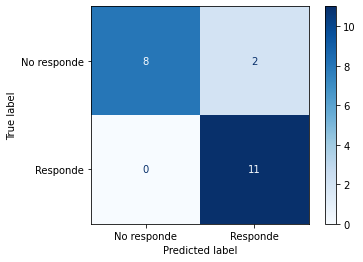

In [ ]:
y_predict_test=ada.predict(X_test)
print(classification_report(y_test,y_predict_test))
cm=confusion_matrix(y_test,y_predict_test)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["No responde", "Responde"])
disp.plot(cmap=plt.cm.Blues)

              precision    recall  f1-score   support

           0       0.67      0.73      0.70        11
           1       0.50      0.43      0.46         7

    accuracy                           0.61        18
   macro avg       0.58      0.58      0.58        18
weighted avg       0.60      0.61      0.60        18



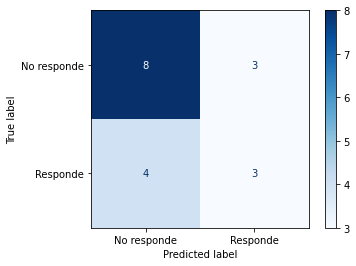

In [ ]:
y_predict_val=ada.predict(X_val)
print(classification_report(y_val,y_predict_val))
cm=confusion_matrix(y_val,y_predict_val)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["No responde", "Responde"])
disp.plot(cmap=plt.cm.Blues)

Los mejores resultados se encuentran con Random Forest. Tiene mejor recall para la categoria de responde.

#Selección de rasgos  - Varianza

In [61]:
import sklearn.feature_selection as fs

Eliminar rasgos con baja varianza

In [62]:
base = pd.DataFrame(balanceado.values)
validacion = pd.DataFrame(X_val)
base.columns = data.columns
validacion.columns = data.columns
sel = fs.VarianceThreshold(threshold=0.01)
sel.fit_transform(base)
sel.get_feature_names_out()
print(base.shape)
print(len(sel.get_feature_names_out()))


(135, 39048)
32699


In [ ]:
#quasi_constant = [col for col in data.columns if col not in sel.get_feature_names_out()]
#len(quasi_constant)

In [63]:
sel.get_feature_names_out()

array(['DDX11L1', 'WASH7P', 'MIR6859-1', ..., 'DAZ3', 'SEPTIN14P23',
       'CSPG4P1Y'], dtype=object)

In [64]:
train = base[sel.get_feature_names_out()]
train

Geneid,DDX11L1,WASH7P,MIR6859-1,LOC729737,DDX11L17,LOC100996442,OR4F29,LOC100132287,MIR12136,LOC100288069,...,PRORY,RBMY2EP,RBMY1A1,LOC105377236,LOC105377237,DAZ1,DAZ2,DAZ3,SEPTIN14P23,CSPG4P1Y
0,0.0,1.977705,1.143320,0.085216,0.048379,4.267878,0.000000,0.000000,39813.505520,1.638593,...,0.0,0.000000,0.0,0.0,0.0,0.000000,0.000000,0.0,0.369339,0.00000
1,0.0,2.611411,1.045155,0.064916,0.000000,6.716911,0.000000,0.000000,36029.767432,1.398044,...,0.0,0.000000,0.0,0.0,0.0,0.000000,0.000000,0.0,0.422034,0.00000
2,0.0,3.052868,6.269957,0.129813,0.000000,2.050954,0.000000,0.016261,68843.657298,0.409364,...,0.0,0.000000,0.0,0.0,0.0,0.000000,0.000000,0.0,0.000000,0.00000
3,0.0,7.888783,25.559079,1.596859,0.000000,7.376984,0.000000,0.011698,44769.426036,0.962461,...,0.0,0.000000,0.0,0.0,0.0,0.000000,0.000000,0.0,0.000000,0.00000
4,0.0,1.820773,6.631364,0.211827,0.000000,3.354015,0.000000,0.000000,53330.736498,0.217234,...,0.0,0.000000,0.0,0.0,0.0,0.000000,0.000000,0.0,0.000000,0.00000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
130,0.0,41.497390,1.474785,26.820929,3.057861,35.301354,0.000000,2.501397,43.786565,53.024281,...,0.0,0.000000,0.0,0.0,0.0,0.000000,0.000000,0.0,2.382075,0.25229
131,0.0,42.098791,0.000000,18.984443,0.487516,42.224683,0.049078,3.089885,4.543555,27.772513,...,0.0,0.086301,0.0,0.0,0.0,0.000000,0.000000,0.0,0.109465,0.00000
132,0.0,14.385957,15.857900,1.083459,0.134205,8.299596,0.000000,0.024676,55103.029232,1.424247,...,0.0,0.000000,0.0,0.0,0.0,0.000000,0.000000,0.0,0.000000,0.00000
133,0.0,15.098842,12.828353,1.403872,0.000000,4.208012,0.044238,0.123573,55039.741838,1.394959,...,0.0,0.000000,0.0,0.0,0.0,0.000000,0.000000,0.0,0.000000,0.00000


También eliminamos los rasgos en el set de validación

In [65]:
val = validacion[sel.get_feature_names_out()]
val

Geneid,DDX11L1,WASH7P,MIR6859-1,LOC729737,DDX11L17,LOC100996442,OR4F29,LOC100132287,MIR12136,LOC100288069,...,PRORY,RBMY2EP,RBMY1A1,LOC105377236,LOC105377237,DAZ1,DAZ2,DAZ3,SEPTIN14P23,CSPG4P1Y
0,0.084330,67.688079,2.048732,55.468474,1.777183,42.614097,0.000000,1.036087,21.583828,31.065196,...,0.000000,0.000000,0.0,0.000000,0.000000,0.0,0.016821,0.000000,0.330912,0.350475
1,0.126170,55.299120,2.043452,128.750180,1.642900,74.235021,0.000000,3.895185,57.734720,41.586851,...,0.000000,0.000000,0.0,0.000000,0.000000,0.0,0.000000,0.000000,0.165029,0.000000
2,0.158175,2.252624,0.000000,0.011934,0.243906,1.330922,0.000000,0.014949,22661.717765,0.486481,...,0.000000,0.000000,0.0,0.330709,0.000000,0.0,0.000000,0.000000,0.000000,0.000000
3,0.000000,2.834191,4.189241,0.676523,0.000000,2.869642,0.000000,0.182524,25456.002490,0.760503,...,3.430212,4.481076,0.0,0.326882,0.000000,0.0,0.000000,0.000000,0.000000,0.000000
4,0.000000,3.210428,4.912844,0.417032,0.000000,4.821093,0.000000,0.000000,31200.571191,0.625869,...,0.000000,0.000000,0.0,0.000000,0.000000,0.0,0.000000,0.000000,0.000000,0.000000
5,0.000000,7.400242,7.382586,0.656073,0.000000,3.605965,0.000000,0.026510,6979.815184,0.689098,...,0.000000,0.000000,0.0,0.026066,0.000000,0.0,0.000000,0.000000,0.183452,0.000000
6,1.158550,143.895994,1.279362,4.275134,9.527940,133.572010,0.185296,1.652338,4.901216,34.214339,...,0.000000,0.000000,0.0,0.000000,0.000000,0.0,0.000000,0.000000,0.309964,1.641445
7,0.000000,5.824941,6.460757,0.744209,0.024853,4.294540,0.170135,0.109673,43107.363466,2.160545,...,0.037572,0.074793,0.0,0.080876,0.025651,0.0,0.000000,0.000000,0.094868,0.000000
8,0.000000,16.319482,0.998933,106.544581,0.000000,35.981940,0.144680,6.637304,11.480695,39.217911,...,0.000000,2.925714,0.0,0.000000,0.000000,0.0,0.000000,0.000000,1.290783,0.000000
9,0.028656,10.195792,5.569355,2.118776,0.353500,9.430396,0.352904,0.205824,146873.854216,0.811497,...,0.000000,0.000000,0.0,0.000000,0.000000,0.0,0.000000,0.000000,0.000000,0.000000


Dividimos nuevamente los datos de entrenamiento y prueba. 

In [66]:
train_x2, test_x, train_y2, test_y= train_test_split(train.values, y2.values, test_size=0.15, random_state=5, stratify=y2.values)

In [67]:
train_x2.shape

(114, 32699)

Comparamos los modelos con validación cruzada

In [ ]:
a , c = cvClassifiers(train.values, y2.values, list_Classifiers)


/usr/local/lib/python3.7/dist-packages/sklearn/linear_model/_logistic.py:818: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  extra_warning_msg=_LOGISTIC_SOLVER_CONVERGENCE_MSG,
/usr/local/lib/python3.7/dist-packages/sklearn/linear_model/_logistic.py:818: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression


In [ ]:
resultado_v = pd.DataFrame()
resultado_v ["Filtro Varianza"] = a
resultado_v ["Modelo"]= name_Classifiers
resultado_v


,Filtro Varianza,Modelo
0,84.505495,Naive Bayes
1,85.769231,Ábol de Decisión
2,84.670330,Regresión Logística
3,100.000000,Support Vector Machine
4,61.538462,KNN
5,53.351648,MLP
6,88.186813,BaggingClassifier
7,85.879121,AdaBoostClassifier
8,58.516484,StackingClassifier
9,85.989011,RandomForest


              precision    recall  f1-score   support

           0       1.00      0.90      0.95        10
           1       0.92      1.00      0.96        11

    accuracy                           0.95        21
   macro avg       0.96      0.95      0.95        21
weighted avg       0.96      0.95      0.95        21



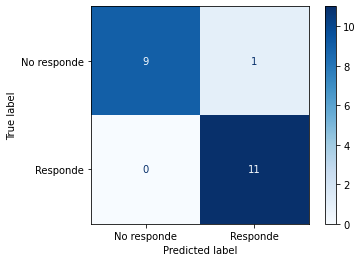

In [ ]:
gbv = GradientBoostingClassifier(n_estimators=10)
gbv.fit(train_x2,train_y2)
y_predict_test=gbv.predict(test_x)
print(classification_report(test_y,y_predict_test))
cm=confusion_matrix(test_y,y_predict_test)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["No responde", "Responde"])
disp.plot(cmap=plt.cm.Blues)

              precision    recall  f1-score   support

           0       0.67      0.91      0.77        11
           1       0.67      0.29      0.40         7

    accuracy                           0.67        18
   macro avg       0.67      0.60      0.58        18
weighted avg       0.67      0.67      0.63        18



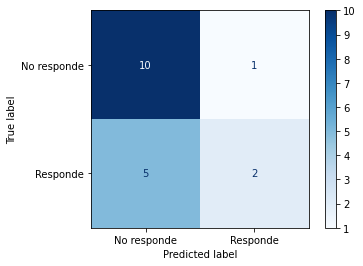

In [ ]:
y_predict_val=gbv.predict(val.values)
print(classification_report(y_val,y_predict_val))
cm=confusion_matrix(y_val,y_predict_val)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["No responde", "Responde"])
disp.plot(cmap=plt.cm.Blues)

Se obtiene el mismo resultado que sin eliminar los datos de baja varianza

Suport vector machine

              precision    recall  f1-score   support

           0       0.83      1.00      0.91        10
           1       1.00      0.82      0.90        11

    accuracy                           0.90        21
   macro avg       0.92      0.91      0.90        21
weighted avg       0.92      0.90      0.90        21



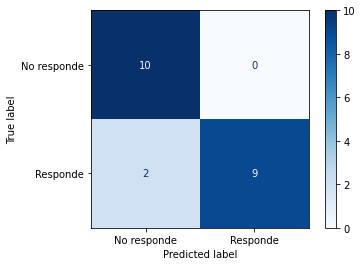

In [ ]:
sv = SVC(kernel='rbf', C=100, gamma=0.1)
sv.fit(train_x2,train_y2)
y_predict_test=sv.predict(test_x)
print(classification_report(test_y,y_predict_test))
cm=confusion_matrix(test_y,y_predict_test)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["No responde", "Responde"])
disp.plot(cmap=plt.cm.Blues)

              precision    recall  f1-score   support

           0       0.61      1.00      0.76        11
           1       0.00      0.00      0.00         7

    accuracy                           0.61        18
   macro avg       0.31      0.50      0.38        18
weighted avg       0.37      0.61      0.46        18



/usr/local/lib/python3.7/dist-packages/sklearn/metrics/_classification.py:1318: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/usr/local/lib/python3.7/dist-packages/sklearn/metrics/_classification.py:1318: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/usr/local/lib/python3.7/dist-packages/sklearn/metrics/_classification.py:1318: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))


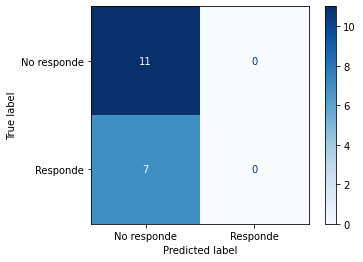

In [ ]:
y_predict_val=sv.predict(val.values)
print(classification_report(y_val,y_predict_val))
cm=confusion_matrix(y_val,y_predict_val)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["No responde", "Responde"])
disp.plot(cmap=plt.cm.Blues)

Se obtienen los mismos resultados que incluyendo datos de baja varianza

Random Forest

              precision    recall  f1-score   support

           0       1.00      0.70      0.82        10
           1       0.79      1.00      0.88        11

    accuracy                           0.86        21
   macro avg       0.89      0.85      0.85        21
weighted avg       0.89      0.86      0.85        21



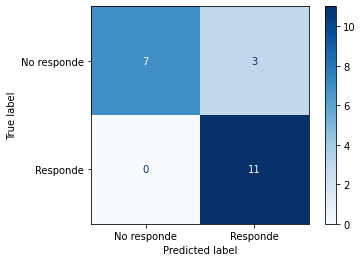

In [ ]:
rfv = RandomForestClassifier()
rfv.fit(train_x2,train_y2)
y_predict_test=rfv.predict(test_x)
print(classification_report(test_y,y_predict_test))
cm=confusion_matrix(test_y,y_predict_test)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["No responde", "Responde"])
disp.plot(cmap=plt.cm.Blues)

              precision    recall  f1-score   support

           0       0.73      1.00      0.85        11
           1       1.00      0.43      0.60         7

    accuracy                           0.78        18
   macro avg       0.87      0.71      0.72        18
weighted avg       0.84      0.78      0.75        18



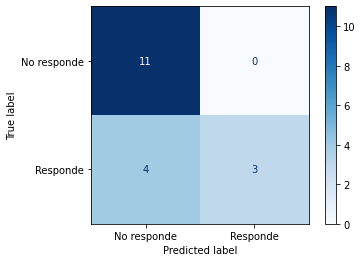

In [ ]:
y_predict_val1=rfv.predict(val.values)
print(classification_report(y_val,y_predict_val1))
cm1=confusion_matrix(y_val,y_predict_val1)
disp = ConfusionMatrixDisplay(confusion_matrix=cm1, display_labels=["No responde", "Responde"])
disp.plot(cmap=plt.cm.Blues)

Mejora un poco la exactitud con respecto al mismo modelo sin excluir rasgos de baja varianza, lo demás permanece constante

Regresión logística

              precision    recall  f1-score   support

           0       0.80      0.80      0.80        10
           1       0.82      0.82      0.82        11

    accuracy                           0.81        21
   macro avg       0.81      0.81      0.81        21
weighted avg       0.81      0.81      0.81        21



/usr/local/lib/python3.7/dist-packages/sklearn/linear_model/_logistic.py:818: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  extra_warning_msg=_LOGISTIC_SOLVER_CONVERGENCE_MSG,


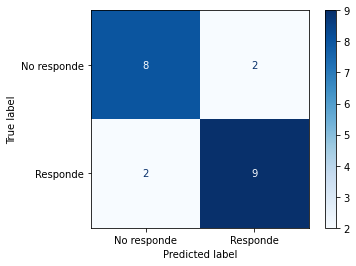

In [ ]:
lrv = LogisticRegression()
lrv.fit(train_x2,train_y2)
y_predict_test=lrv.predict(test_x)
print(classification_report(test_y,y_predict_test))
cm=confusion_matrix(test_y,y_predict_test)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["No responde", "Responde"])
disp.plot(cmap=plt.cm.Blues)

              precision    recall  f1-score   support

           0       0.67      0.73      0.70        11
           1       0.50      0.43      0.46         7

    accuracy                           0.61        18
   macro avg       0.58      0.58      0.58        18
weighted avg       0.60      0.61      0.60        18



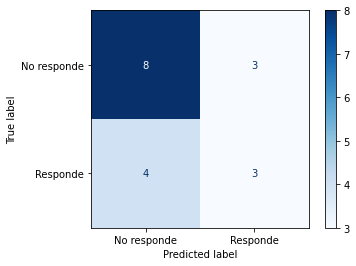

In [ ]:
y_predict_val=lrv.predict(val.values)
print(classification_report(y_val,y_predict_val))
cm=confusion_matrix(y_val,y_predict_val)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["No responde", "Responde"])
disp.plot(cmap=plt.cm.Blues)

Se decide continuar con Random Forest pues tiene mejor exactitud en el set de validación, además de un mejor recall para la clase responde. Se buscará mejorar el modelo random forest con selección de rasgos y tunning de parámetros.

#SelectKBest

In [119]:
X_train2, X_test, y_train2, y_test= train_test_split(balanceado.values, y2.values, test_size=0.15, random_state=5, stratify=y2.values)

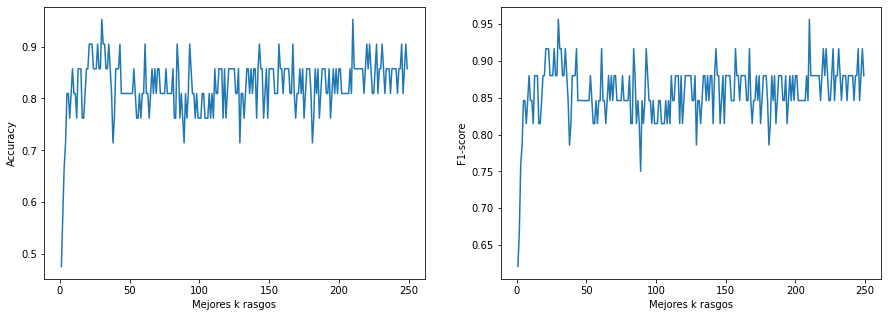

In [120]:
f1_list = []
accuracy_list=[]
for k in range(1, 250):
  #bk = SelectKBest(fs.f_classif, k=k)
  bk = SelectKBest(score_func=chi2, k=k)
  bk.fit(X_train2, y_train2)
  X_train_trans = bk.transform(X_train2)
  X_test_trans = bk.transform(X_test)
  rfb = RandomForestClassifier()
  rfb.fit(X_train_trans, y_train2)
  y_pred = rfb.predict(X_test_trans)
  accuracy=metrics.accuracy_score(y_test, y_pred)
  accuracy_list.append(accuracy)
  f1 = metrics.f1_score(y_test, y_pred)
  f1_list.append(f1)

fig, axe = plt.subplots(1,2,figsize=(15,5))
axe[0].plot(range(1, 250), accuracy_list)
axe[0].set_xlabel("Mejores k rasgos")
axe[0].set_ylabel("Accuracy")
axe[1].plot(range(1, 250), f1_list)
axe[1].set_xlabel("Mejores k rasgos")
axe[1].set_ylabel("F1-score")
plt.show()

In [121]:
np.argmax(accuracy_list)

29

In [122]:
accuracy_list[np.argmax(accuracy_list)]

0.9523809523809523

Creamos una matriz con los 20 seleccionados

In [123]:
test = SelectKBest(score_func=chi2, k=20)
fit = test.fit(X_train2, y_train2)

np.set_printoptions(precision=3)
print(fit.scores_)

features = fit.transform(balanceado.values)
features_val = fit.transform(X_val)
print(features[0:5,:])

[ 1.291 59.468 14.387 ...  0.266  0.073  0.395]
[[8.955e+00 6.425e-01 2.065e-01 4.763e-01 0.000e+00 1.934e+00 1.885e+03
  2.007e+00 3.479e+01 1.486e+00 6.188e-01 4.057e+02 0.000e+00 4.135e+00
  8.271e+00 1.520e-01 0.000e+00 3.097e+01 9.159e+01 1.224e+02]
 [4.515e+01 8.125e+00 1.133e+00 3.204e+00 6.746e-01 1.021e+00 6.873e+03
  3.718e+00 6.012e+01 3.078e+01 8.228e-01 1.633e+04 0.000e+00 0.000e+00
  0.000e+00 9.729e-01 3.870e-01 0.000e+00 7.718e+02 7.739e+03]
 [5.333e+00 1.272e+00 1.604e+00 2.084e+00 2.361e-01 6.403e+00 1.680e+03
  9.558e+00 9.875e+01 2.999e+02 2.828e+00 1.289e+00 2.268e+00 0.000e+00
  4.536e+00 7.875e-01 0.000e+00 6.022e-01 6.662e-01 0.000e+00]
 [7.761e+01 1.373e+01 0.000e+00 2.103e+00 1.395e+01 1.539e+02 3.689e+03
  3.473e-02 3.494e+02 1.562e+02 7.398e-02 1.885e+03 0.000e+00 0.000e+00
  5.438e-01 2.431e+02 1.855e+00 1.035e+02 1.824e+03 1.486e+03]
 [4.913e+01 1.615e+01 0.000e+00 2.819e-02 0.000e+00 3.561e-02 4.627e+00
  0.000e+00 6.189e+01 3.353e+02 0.000e+00 3.829e+04 

In [124]:
seleccionados = fit.get_support(indices=False)
genes=[]
print(len(seleccionados))
print(guardar.columns.shape)
for i in range(len(seleccionados)):
  if seleccionados[i]==True:
    genes.append(guardar.columns[i])
genes

39048
(39049,)


['S100A9',
 'S100A8',
 'GKN1',
 'ALB',
 'FGG',
 'PGC',
 'TYRP1',
 'LIPF',
 'H19',
 'HBB',
 'PGA5',
 'IGHG1',
 'SNORD116-15',
 'SNORD116-16',
 'SNORD116-24',
 'HP',
 'PI3',
 'IGLV2-11',
 'IGLC2',
 'IGLC3']

Dividimos los datos de entrenamiento y prueba para esa nueva matriz. Entrenamos con Random Forest

In [ ]:
train_x3, test_x1, train_y3, test_y1= train_test_split(features, y2.values, test_size=0.15, random_state=5, stratify=y2.values)


              precision    recall  f1-score   support

           0       1.00      0.80      0.89        10
           1       0.85      1.00      0.92        11

    accuracy                           0.90        21
   macro avg       0.92      0.90      0.90        21
weighted avg       0.92      0.90      0.90        21



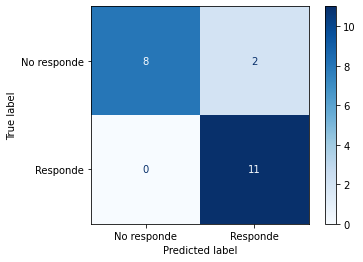

In [ ]:
rfb = RandomForestClassifier()
rfb.fit(train_x3,train_y3)
y_predict_test1=rfb.predict(test_x1)
print(classification_report(test_y1,y_predict_test1))
cm=confusion_matrix(test_y1,y_predict_test1)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["No responde", "Responde"])
disp.plot(cmap=plt.cm.Blues)

              precision    recall  f1-score   support

           0       0.83      0.91      0.87        11
           1       0.83      0.71      0.77         7

    accuracy                           0.83        18
   macro avg       0.83      0.81      0.82        18
weighted avg       0.83      0.83      0.83        18



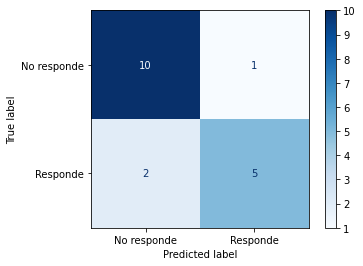

In [ ]:
y_predict_val1=rfb.predict(features_val)
print(classification_report(y_val,y_predict_val1))
cm=confusion_matrix(y_val,y_predict_val1)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["No responde", "Responde"])
disp.plot(cmap=plt.cm.Blues)

Se obtienen muy buenos resultados con random forest y esos 20 genes

In [ ]:
features

array([[8.955e+00, 6.425e-01, 2.065e-01, ..., 3.097e+01, 9.159e+01,
        1.224e+02],
       [4.515e+01, 8.125e+00, 1.133e+00, ..., 0.000e+00, 7.718e+02,
        7.739e+03],
       [5.333e+00, 1.272e+00, 1.604e+00, ..., 6.022e-01, 6.662e-01,
        0.000e+00],
       ...,
       [1.989e+02, 4.961e+01, 1.432e-01, ..., 3.046e-01, 1.348e+01,
        6.066e+00],
       [7.083e+01, 1.774e+01, 2.758e-01, ..., 6.442e+01, 2.352e+03,
        2.895e+02],
       [5.745e+00, 1.134e+01, 9.108e-02, ..., 1.556e+02, 2.231e+03,
        4.743e+02]])

### Forward Selection
No finaliza

In [ ]:
sfs = fs.SequentialFeatureSelector( RandomForestClassifier(n_estimators=10), n_features_to_select=30, cv=10)

In [ ]:
sfs.fit(X_train2, y_train2)

In [ ]:
sfs.get_feature_names_out()

In [ ]:
train_s = train[sfs.get_feature_names_out()]
train_s

In [ ]:
train_x1, val_x1, train_y1, val_y1= train_test_split(train_s, y, test_size=0.1, random_state=5, stratify=y)
train_x3, test_x1, train_y3, test_y1= train_test_split(train_x1, train_y1, test_size=0.15, random_state=5, stratify=train_y1)


In [ ]:
gbb = GradientBoostingClassifier(n_estimators=10)
gbb.fit(train_x3,train_y3)
y_predict_test=gbb.predict(test_x1)
print(classification_report(test_y1,y_predict_test))
cm=confusion_matrix(test_y1,y_predict_test)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["No responde", "Responde"])
disp.plot(cmap=plt.cm.Blues)

In [ ]:
y_predict_val=gbb.predict(val_x1)
print(classification_report(val_y1,y_predict_val))
cm=confusion_matrix(val_y1,y_predict_val)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["No responde", "Responde"])
disp.plot(cmap=plt.cm.Blues)

#Selección basada en árbol

In [ ]:
from sklearn.feature_selection import SelectFromModel

In [ ]:
gbs = RandomForestClassifier()
gbs.fit(balanceado.values, y2.values)
print(gbs.feature_importances_)

[0. 0. 0. ... 0. 0. 0.]


In [ ]:
from pandas.core.tools.datetimes import DatetimeScalar
model = fs.SelectFromModel(gbs, prefit=True)
X_trans = model.transform(balanceado.values)
val_trans = model.transform(X_val)
print(balanceado.shape)
print(X_trans.shape)
print(X_val.shape)
print(val_trans .shape)

(135, 39048)
(135, 962)
(18, 39048)
(18, 962)


Se organizó la base de conocimiento y el set de validación, dejando solo 962 rasgos

In [ ]:
indexs=data.columns

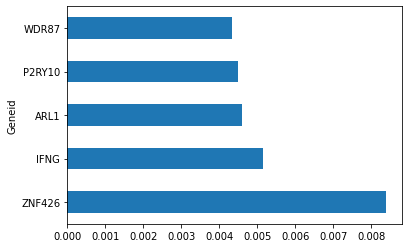

In [ ]:
n=len(gbs.feature_importances_)
(pd.Series(gbs.feature_importances_, index=indexs)
   .nlargest(5)
   .plot(kind='barh'))  

In [ ]:
#X_train_a, X_val_a, y_train_a, y_val_a= train_test_split(X_trans, y, test_size=0.1, random_state=5, stratify=y)
X_train_a2, X_test_a, y_train_a2, y_test_a= train_test_split(X_trans, y2.values, test_size=0.15, random_state=5, stratify=y2.values)
print(np.unique(y,return_counts=True))
print(np.unique(y_train,return_counts=True))
print(np.unique(y_test,return_counts=True))
print(np.unique(y_val,return_counts=True))


(array([0, 1]), array([74, 43]))
(array([0, 1]), array([63, 36]))
(array([0, 1]), array([10, 11]))
(array([0, 1]), array([11,  7]))


              precision    recall  f1-score   support

           0       1.00      0.80      0.89        10
           1       0.85      1.00      0.92        11

    accuracy                           0.90        21
   macro avg       0.92      0.90      0.90        21
weighted avg       0.92      0.90      0.90        21



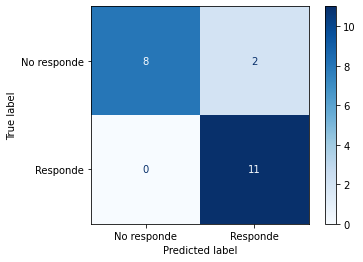

In [ ]:
rfa = RandomForestClassifier()
rfa.fit(X_train_a2, y_train_a2)

y_predict_testa=rfa.predict(X_test_a)
print(classification_report(y_test_a,y_predict_testa))
cm=confusion_matrix(y_test_a,y_predict_testa)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["No responde", "Responde"])
disp.plot(cmap=plt.cm.Blues)

              precision    recall  f1-score   support

           0       0.71      0.91      0.80        11
           1       0.75      0.43      0.55         7

    accuracy                           0.72        18
   macro avg       0.73      0.67      0.67        18
weighted avg       0.73      0.72      0.70        18



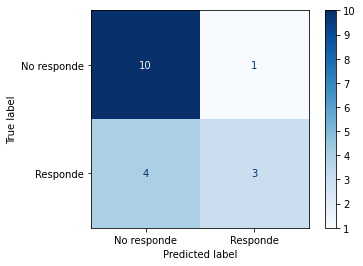

In [ ]:
y_predict_test=rfa.predict(val_trans)
print(classification_report(y_val,y_predict_test))
cm=confusion_matrix(y_val,y_predict_test)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["No responde", "Responde"])
disp.plot(cmap=plt.cm.Blues)

Se obtiene un buen resultado pero es mejor con select K Best

# Con Análisis de componentes principales

In [ ]:
from sklearn.svm import SVC
from sklearn.svm import SVR
from sklearn.pipeline import make_pipeline
from sklearn.model_selection import GridSearchCV

In [ ]:
pca=PCA(115,svd_solver='randomized', whiten=True)

In [ ]:
rfp = RandomForestClassifier()
model = make_pipeline(pca, rfp)

In [ ]:
model.fit(balanceado.values, y2.values)

Pipeline(steps=[('pca',
                 PCA(n_components=115, svd_solver='randomized', whiten=True)),
                ('randomforestclassifier', RandomForestClassifier())])

              precision    recall  f1-score   support

           0       0.00      0.00      0.00        10
           1       0.52      1.00      0.69        11

    accuracy                           0.52        21
   macro avg       0.26      0.50      0.34        21
weighted avg       0.27      0.52      0.36        21



/usr/local/lib/python3.7/dist-packages/sklearn/metrics/_classification.py:1318: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/usr/local/lib/python3.7/dist-packages/sklearn/metrics/_classification.py:1318: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/usr/local/lib/python3.7/dist-packages/sklearn/metrics/_classification.py:1318: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))


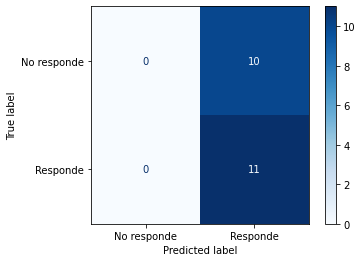

In [ ]:
yfit = model.predict(X_test)
print(classification_report(y_test,yfit))
cm=confusion_matrix(y_test,yfit)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["No responde", "Responde"])
disp.plot(cmap=plt.cm.Blues)

              precision    recall  f1-score   support

           0       0.00      0.00      0.00        11
           1       0.39      1.00      0.56         7

    accuracy                           0.39        18
   macro avg       0.19      0.50      0.28        18
weighted avg       0.15      0.39      0.22        18



/usr/local/lib/python3.7/dist-packages/sklearn/metrics/_classification.py:1318: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/usr/local/lib/python3.7/dist-packages/sklearn/metrics/_classification.py:1318: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/usr/local/lib/python3.7/dist-packages/sklearn/metrics/_classification.py:1318: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))


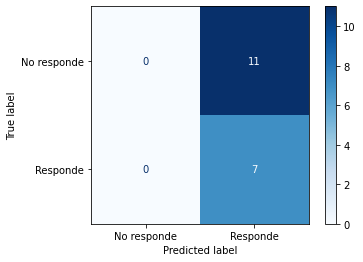

In [ ]:
yfit = model.predict(X_val)
print(classification_report(y_val,yfit))
cm=confusion_matrix(y_val,yfit)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["No responde", "Responde"])
disp.plot(cmap=plt.cm.Blues)

No realiza una buena clasificación

#Búsqueda de parámetros para random forest

Se realizará un tunnig de los parámetros de random forest con 20 rasgos

In [ ]:
param_grid = {'n_estimators':[10, 50, 100, 500],
            'criterion':["gini", "entropy"],
            'max_depth': [10, 50, 100, None],
            'min_samples_leaf': [1, 2, 4],
            'min_samples_split': [2, 5, 10]}

rff = RandomForestClassifier()
rff_cv= GridSearchCV(rff,param_grid,cv=10)
rff_cv.fit(features,y2.values)
print(rff_cv.best_score_,rff_cv.best_params_)


0.8906593406593405 {'criterion': 'entropy', 'max_depth': None, 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 500}


              precision    recall  f1-score   support

           0       1.00      0.80      0.89        10
           1       0.85      1.00      0.92        11

    accuracy                           0.90        21
   macro avg       0.92      0.90      0.90        21
weighted avg       0.92      0.90      0.90        21



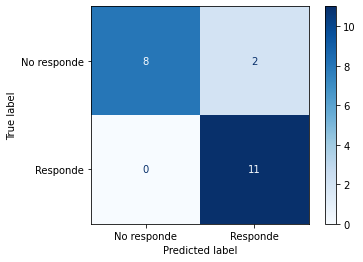

In [ ]:
rff = RandomForestClassifier(n_estimators=500, criterion="entropy", max_depth=None, min_samples_leaf=1, min_samples_split=2)
rff.fit(train_x3,train_y3)
y_predict_test=rff.predict(test_x1)
print(classification_report(test_y1,y_predict_test))
cm=confusion_matrix(test_y1, y_predict_test)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["No responde", "Responde"])
disp.plot(cmap=plt.cm.Blues)

              precision    recall  f1-score   support

           0       0.83      0.91      0.87        11
           1       0.83      0.71      0.77         7

    accuracy                           0.83        18
   macro avg       0.83      0.81      0.82        18
weighted avg       0.83      0.83      0.83        18



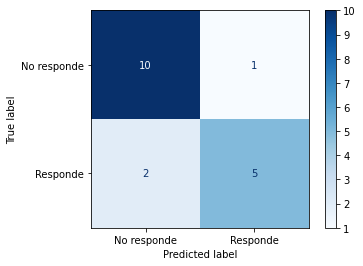

In [ ]:
y_predict_val=rff.predict(features_val)
print(classification_report(y_val,y_predict_val))
cm=confusion_matrix(y_val, y_predict_val)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["No responde", "Responde"])
disp.plot(cmap=plt.cm.Blues)


In [ ]:
from sklearn.metrics import roc_auc_score
y_score = rff.predict_proba(features_val)[:, 1]
roc_auc_score(y_val, y_score)

0.8571428571428572

Se logra entrenar un modelo Random forest con 20 genes seleccionados utilizando best k select. Los parámentros son: (n_estimators=500, criterion="entropy", max_depth=None, min_samples_leaf=1, min_samples_split=2).

Se logra una exactitud de 0.83, un recall de 0.91 u 0.71, precisión 0.83 y AUC 0.85. Con un set de entrenamiento  de 99 pacientes y un set de validación de 18

# Comparación con la literatura

**A Machine Learning Model to Predict the Triple Negative Breast Cancer Immune Subtype**

Zihao Chen, 1 , † Maoli Wang, 2 , † Rudy Leon De Wilde, 3 Ruifa Feng, 4 Mingqiang Su, 5 Luz Angela Torres-de la Roche,  3 , * and Wenjie Shi  3 , *

Se seleccionaron 11 genes a partir de la caracterización de dos subtipos inmunes encontrados en el TNBC: LCK, IL2RG, CD3G, STAT1, CD247, IL2RB, CD3D, IRF1, OAS2, IRF4, and IFNG. Se entrenó un algoritmo de random forest con una AUC de 0.76. Se utilizó gridsearch para hacer tunning de losparámetros. Set de entrenamiento y preuba de 313 pacientes (70% entrenamiento, 30% prueba)

https://www.ncbi.nlm.nih.gov/pmc/articles/PMC8484710/


**Immune gene signatures for predicting durable clinical benefit of anti-PD-1 immunotherapy in patients with non-small cell lung cancer**

Sohyun Hwang,#1 Ah-Young Kwon,#1 Ju-Yeon Jeong,2 Sewha Kim,1 Haeyoun Kang,1 Joonsuk Park,3 Joo-Hang Kim,4 Ok Jin Han,2 Sun Min Lim, 4 and Hee Jung An 1

Utilizaron modelos de random forest para probar un panel de expresión de 393 genes. Utilizaron leave-one-out cross-validation, encontrando que el modelo con 3 genes (CD137, PSMB9, and BCL-2) tuvo el mejor desempeño: sensitivity = 0.67, specificity = 0.75, and accuracy = 0.71. Se utilizaron los parámetros por defecto. Se trabajó con 21 pacientes.

Otros predictores de respuesta tienen el siguiente desempeño: 
PDL1 y TILs: AUC 0.6
TMB: AUC 0.74
https://www.ncbi.nlm.nih.gov/pmc/articles/PMC6971301/



**ISPRF: A machine learning model to predict the immune subtype of kidney cancer samples by four genes**

Zhifeng Wang1#, Zihao Chen2#, Hongfan Zhao2, Hao Lin2, Junjie Wang1, Ning Wang1, Xiqing Li3, Degang Ding1

Se utiliza aprendizaje no supervisado a partir de los valores de población de células inmunes para identificar clústeres. Luego se utiliza “Weighted correlation network analysis” para encontrar los genes que diferencian cada subtipo (CTLA4, FOXP3, IFNG, and CD19). Se utilizó un modelo random forest a partir de datos de mRNA de los 4 genes para identificar los subtipos, con un AUC de 0,78 con parámetros de (mtry =2, ntree =300).  El subtipo dos tiene una mejor respuesta a la inmunoterapia. Se utilizó un set de entrenaimiento de 831 pacientes y un set de valización de 348


**Tumor mutational burden related classifier is predictive of response to PD-L1 blockade in locally advanced and metastatic urothelial carcinoma**. 2020 

YejinpengWanga LiangChena LingaoJubcdg YuXiaoabcdfg Xinghuan Wangaeg

Realizaron análisis de expression diferencial de genes entre tumores con TMB alto y bajo, para seleccionar los principales rasgos. Se hizo reducción de rasgos con SVM-RFE. Luego se entrenaron 9 modelos (ADA, KNN, Lasso, MARS, Nnet, RF, svmLinear, svmRadical, XGBDART), encontrando Lasso logistic regression como el de major desempeño, con un AUC de 93.0% [89.6%–95.4%]) accuracy de 0.82. En un set de entrenamiento de 169 pacientes y un set de prueba de 109 pacientes.


**Machine learning reveals a PD-L1eindependent prediction of response to immunotherapy of non-small cell lung cancer by gene expression context**

Marcel Wiesweg a,f,g , Fabian Mairinger b , Henning Reis b , Moritz Goetz b , Jens Kollmeier i , Daniel Misch i , Susann Stephan-Falkenau j , Thomas Mairinger j , Robert F.H. Walter b,e , Thomas Hager b , Martin Metzenmacher a,f , Wilfried E.E. Eberhardt a,f , Gregor Zaun a , Johannes Ko¨ster g , Martin Stuschke c,h , Clemens Aigner d,h , Kaid Darwiche e , Kurt W. Schmid b,h , Sven Rahmann g,h , Martin Schuler a,f,h, *

Se entrenan modelos a partir de microarrays. El mejor algoritmo de respuesta fue support vector machine con un kernel sigmoide. Se utilizó lasso para la selección de rasgos. No se tiene acceso a los resultados. 
https://pubmed.ncbi.nlm.nih.gov/33059196/



#Pendientes

1. Revisar la regresión logística con los datos estandarizados y balanceados
2. Seguir probando con selección de rasgos el Gradient boosting
2. Encontrar otro método para la eliminación de batch
3. Ampliar la base de conocimiento
4. Analizar los genes resultantes


---

